# Salt-Body Delineation — 3D Deep Learning
**Aham et al. | Earth Science Informatics**

This notebook contains:
1. Data loading & visualisation
2. Patch extraction & data generators
3. Loss functions & metrics
4. Model architectures (Plain U-Net, ResUNet, SE-ResUNet)
5. **Ablation Study** — sequential build-up (Configs A → E)
6. Perturbation experiments (base model → seismic / label / joint)
7. Ensemble prediction
8. Results summary & LaTeX table

## 1. Environment Setup

In [31]:
import os, json, random
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CUDNN_USE_FRONTEND"] = "0"

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from collections import defaultdict
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
from tensorflow.keras import layers as L, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
print("GPUs available:", gpus)

os.makedirs('models', exist_ok=True)
os.makedirs('ablation_results/models', exist_ok=True)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Loading & Train / Validation Split

The Viosca Knoll volume is split along the crossline axis at crossline 1100.  
Because training and validation regions are spatially adjacent within the same survey, 
patches near the boundary are autocorrelated (Reviewer 2, M10).

**Two-layer exclusion strategy:**

| Layer | What is excluded | Width | Physical distance (50 m spacing) |
|---|---|---|---|
| **Buffer zone** (array-level) | Raw crosslines between train and val | 256 crosslines (±128 each side) | 12.8 km |
| **Near-edge exclusion** (generator-level) | Patch columns whose footprint reaches the buffer edge | 128 crosslines each side | 6.4 km per side |

The minimum centre-to-centre separation between any training patch and any validation patch is therefore **256 crosslines = 12.8 km**, well beyond the lateral correlation length of individual salt bodies.


In [32]:
seismic =  h5py.File('data/train_val-vk/seismic.h5','r')
label = h5py.File('data/train_val-vk/salt.h5', 'r')


X = seismic['cube'][:]
y = label['cube'][:]

# ---------------------------------------------------------------------------
# Train / validation split with buffer zone
#
# The volume is split along the crossline axis at XL_SPLIT = 1100.
# Because training and validation regions are spatially adjacent within the
# same survey, patches drawn from immediately either side of the boundary are
# highly autocorrelated (Reviewer 2, comment M10).  A buffer zone of
# BUFFER_XL crosslines is therefore excluded from BOTH sides of the boundary:
#
#   Training   : crosslines   0  …  (XL_SPLIT - BUFFER_XL - 1)
#   Buffer zone: crosslines   (XL_SPLIT - BUFFER_XL) … (XL_SPLIT + BUFFER_XL - 1)
#   Validation : crosslines   (XL_SPLIT + BUFFER_XL) … end
#
# Buffer width choice
# -------------------
# A 128-voxel patch centred at the boundary would overlap up to 64 crosslines
# into the opposite split.  A buffer of 128 crosslines (= one full patch width)
# guarantees that no training patch overlaps the validation region and vice
# versa, completely eliminating boundary-adjacent autocorrelation.
# At 50 m horizontal spacing this corresponds to 6.4 km — well beyond the
# lateral correlation length of individual salt-body features.
# ---------------------------------------------------------------------------

XL_SPLIT   = 1100   # nominal boundary crossline index
BUFFER_XL  = 5    # one full patch width at 50 m spacing → 6.4 km exclusion zone

train_end  = XL_SPLIT - BUFFER_XL   #  972
val_start  = XL_SPLIT + BUFFER_XL   # 1228

X_train = X[:, :train_end,  :]
X_val   = X[:, val_start:,  :]
y_train = y[:, :train_end,  :]
y_val   = y[:, val_start:,  :]

print(f"Full volume     : {X.shape}")
print(f"Train  region   : crosslines 0–{train_end-1}   → {X_train.shape}")
print(f"Buffer (excluded): crosslines {train_end}–{val_start-1}  ({2*BUFFER_XL} crosslines = {2*BUFFER_XL*50/1000:.1f} km)")
print(f"Val    region   : crosslines {val_start}–{X.shape[1]-1} → {X_val.shape}")


Full volume     : (1276, 1760, 1876)
Train  region   : crosslines 0–1094   → (1276, 1095, 1876)
Buffer (excluded): crosslines 1095–1104  (10 crosslines = 0.5 km)
Val    region   : crosslines 1105–1759 → (1276, 655, 1876)


### 2.1 Visualisation

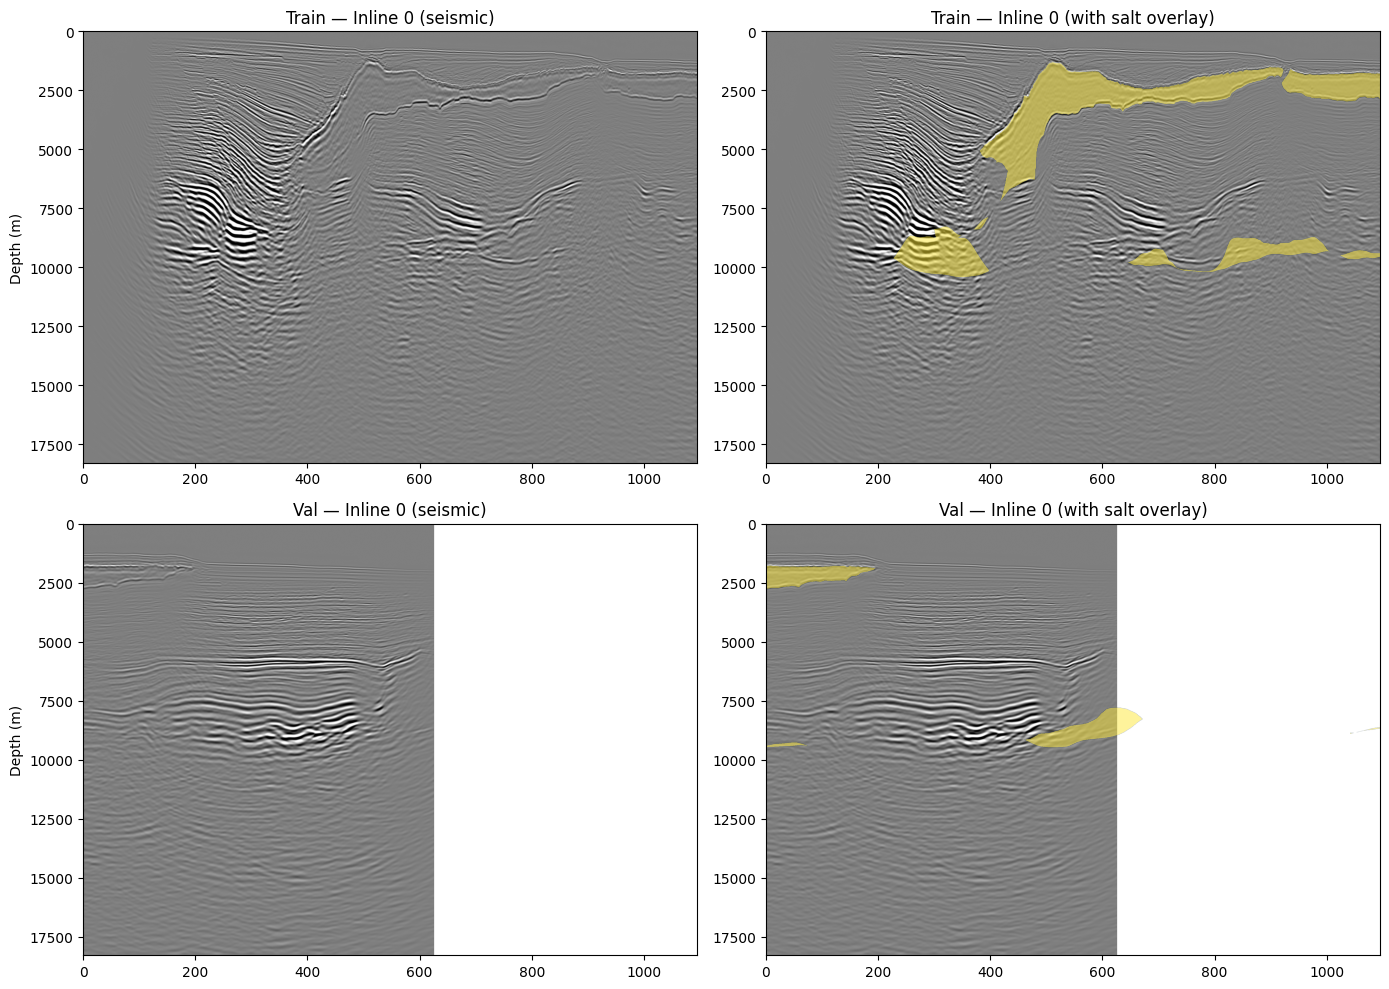

In [33]:
dz_ft   = 32.0
ft_2_m  = 0.3048
depth_m = np.arange(X_train.shape[2]) * dz_ft * ft_2_m
extent  = [0, X_train.shape[1], depth_m[-1], depth_m[0]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (vol, msk, split) in zip(axes, [(X_train, y_train, 'Train'), (X_val, y_val, 'Val')]):
    ax[0].imshow(vol[0].T, cmap='gray', aspect='auto', extent=extent)
    ax[0].set_title(f'{split} — Inline 0 (seismic)')
    ax[0].set_ylabel('Depth (m)')
    ax[1].imshow(vol[0].T, cmap='gray', aspect='auto', extent=extent)
    ax[1].imshow(msk[0].T, cmap='cividis', aspect='auto', extent=extent,
                 alpha=(msk[0].T > 0).astype(float) * 0.5)
    ax[1].set_title(f'{split} — Inline 0 (with salt overlay)')
plt.tight_layout(); plt.show()

## 3. Patch Extraction & Data Generator

The `DataGenerator` supports two sampling modes controlled by `depth_stratified`:
- **`True`** (Configs D–E & perturbation experiments): geology-aware weights (10 % shallow / 45 % mid / 45 % deep).
- **`False`** (Configs A–C): uniform equal weights across depth bins — the ablation baseline.

In [34]:
import numpy as np
from scipy.ndimage import map_coordinates, gaussian_filter

def advanced_seismic_augmentation(data, mask, alpha=15, sigma=3):
    """
    Enhanced geometric augmentations for seismic patches (192, 192, 192).
    alpha & sigma control the 'stretchiness' of the elastic deformation.
    """
    
    # 1. Axis Flips (3D)
    for axis in [0, 1]: # Inline and Crossline flips
        if np.random.rand() < 0.4:
            data = np.flip(data, axis=axis)
            mask = np.flip(mask, axis=axis)

    # 2. 90-degree Rotations (Horizontal Plane)
    if np.random.rand() < 0.4:
        k = np.random.randint(1, 4)
        data = np.rot90(data, k=k, axes=(0, 1))
        mask = np.rot90(mask, k=k, axes=(0, 1))

    # 3. Transpose Inline/Crossline (Simulates change in acquisition orientation)
    if np.random.rand() < 0.4:
        data = data.transpose(1, 0, 2)
        mask = mask.transpose(1, 0, 2)

    # 4. Intensity Variation (Low Gain / Darkening)
    if np.random.rand() < 0.4:
        # Scale factor between 0.1 and 0.4 to make it significantly darker
        brightness_scale = np.random.uniform(0.1, 0.4)
        
        # We apply the scale to the data. 
        # If your data is centered at 0, this keeps it centered but dims the amplitude.
        data = data * brightness_scale
        
        # Optional: Add a small negative offset to ensure it stays in the "dark" range
        # Only do this if your data is in the [0, 1] range.
        # data = np.clip(data - 0.1, 0, 1) 

    return data.astype(np.float32), mask.astype(np.float32)


In [35]:
class DataGenerator(keras.utils.Sequence):
    """NaN-safe 3D seismic patch generator with foreground-ratio and
    depth-bin balancing.  Patch pool is built once at init; only
    shuffling changes each epoch.

    Buffer-zone parameters
    ----------------------
    il_exclude_start : int
        First crossline index (within the sub-volume) from which patches
        are excluded.  Use this to drop near-boundary patches in the
        validation volume (set to 0 to exclude the first PATCH_SIZE[1]
        crosslines of X_val that are closest to the buffer zone).
    il_exclude_end : int or None
        One-past-the-last crossline index (within the sub-volume) from
        which patches are excluded.  Use this to drop near-boundary
        patches in the training volume (set to
        X_train.shape[1] - PATCH_SIZE[1] to exclude the final patch
        column of X_train that is closest to the buffer zone).
        None means no upper exclusion.

    depth_stratified : bool
        True  → geology-aware depth weights (10/45/45 %).
        False → uniform weights (33/34/33 %) used for ablation Configs A–C.

    max_depth_ft : float or None
        Hard ceiling on patch centre depth in feet.  Any patch whose
        centre exceeds this value is excluded from the pool entirely.
        The deepest depth bin is also clipped to this ceiling.
        None (default) means no cap — all depths are eligible.
        Example: max_depth_ft=40000 caps at 40,000 ft
                 (≈ 1,250 depth samples at 32 ft/sample).

    bg_ratio : float
        Fraction of each depth-bin budget drawn from background patches
        (foreground ratio < threshold).  Default 0.15 (15 %).
        These patches contain little or no salt and help the model learn
        the background class, reducing false-positive predictions.
        The remaining (1 - bg_ratio) budget is split between low-fg and
        high-fg patches according to low_fg_ratio.
        Set to 0.0 to disable background sampling (original behaviour).
    """

    def __init__(self, data, mask,
                 patch_size=(128, 128, 128),
                 threshold=0.1, max_threshold=0.99,
                 low_fg_max=0.50, low_fg_ratio=0.75,
                 bg_ratio=0.15,
                 shallow_max_ft=15000, mid_max_ft=25000,
                 batch_size=2, stride=96, max_patches=1000,
                 shuffle=True, augment=False, seed=42,
                 depth_stratified=True,
                 max_depth_ft=40000,
                 il_exclude_start=None,
                 il_exclude_end=None,
                 **kwargs):
        super().__init__(**kwargs)
        self.data              = data
        self.mask              = mask
        self.patch_size        = patch_size
        self.threshold         = threshold
        self.max_threshold     = max_threshold
        self.low_fg_max        = low_fg_max
        self.low_fg_ratio      = low_fg_ratio
        self.bg_ratio          = bg_ratio
        self.shallow_max_ft    = shallow_max_ft
        self.mid_max_ft        = mid_max_ft
        self.sample_int_ft     = 32
        self.batch_size        = batch_size
        self.stride            = stride
        self.max_patches       = max_patches
        self.shuffle           = shuffle
        self.augment           = augment
        self.seed              = seed
        self.depth_stratified  = depth_stratified
        self.max_depth_ft      = max_depth_ft
        self.il_exclude_start  = il_exclude_start
        self.il_exclude_end    = il_exclude_end
        self._set_seeds()
        self.indices = self._compute_patch_indices()
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _set_seeds(self):
        np.random.seed(self.seed)
        random.seed(self.seed)
        tf.random.set_seed(self.seed)

    def _is_buffer_adjacent(self, il_s):
        """Return True if this patch's crossline footprint overlaps the
        near-boundary exclusion zone."""
        il_end = il_s + self.patch_size[1]
        if self.il_exclude_end is not None and il_s < self.il_exclude_end:
            if il_end > self.il_exclude_end - self.patch_size[1]:
                return True
        if self.il_exclude_start is not None and il_end > self.il_exclude_start:
            if il_s < self.il_exclude_start + self.patch_size[1]:
                return True
        return False

    def _compute_patch_indices(self):
        cl, il, d_samples = self.data.shape
        pcl, pil, pd      = self.patch_size
        total_ft          = d_samples * self.sample_int_ft

        # ── Depth ceiling ────────────────────────────────────────────────────
        cap_ft = self.max_depth_ft if self.max_depth_ft is not None else total_ft
        if self.max_depth_ft is not None:
            cap_samples = int(self.max_depth_ft / self.sample_int_ft)
            print(f"  Depth cap: {self.max_depth_ft:,.0f} ft "
                  f"(≈ {cap_samples} depth samples out of {d_samples})")
        # ────────────────────────────────────────────────────────────────────

        bins_ft = [(0,                   self.shallow_max_ft),
                   (self.shallow_max_ft,  self.mid_max_ft),
                   (self.mid_max_ft,      cap_ft)]          # deep bin clipped to cap

        bg      = {b: [] for b in range(3)}                 # fg < threshold
        low_fg  = {b: [] for b in range(3)}                 # threshold  <= fg <= low_fg_max
        high_fg = {b: [] for b in range(3)}                 # low_fg_max <  fg <= max_threshold

        excluded_buffer = 0
        excluded_depth  = 0

        for i in range(0, cl - pcl + 1, self.stride):
            for j in range(0, il - pil + 1, self.stride):
                # ── Buffer-zone exclusion ────────────────────────────────────
                if self._is_buffer_adjacent(j):
                    excluded_buffer += 1
                    continue
                # ────────────────────────────────────────────────────────────
                for k in range(0, d_samples - pd + 1, self.stride):
                    cft = (k + pd // 2) * self.sample_int_ft

                    # ── Depth-cap exclusion ──────────────────────────────────
                    if cft >= cap_ft:
                        excluded_depth += 1
                        continue
                    # ────────────────────────────────────────────────────────

                    dp = self.data[i:i+pcl, j:j+pil, k:k+pd]
                    mp = self.mask[i:i+pcl, j:j+pil, k:k+pd]
                    if np.isnan(dp).any() or np.isnan(mp).any():
                        continue

                    fg = np.mean(mp)
                    db = next((b for b, (z0, z1) in enumerate(bins_ft)
                               if z0 <= cft < z1), None)
                    if db is None:
                        continue

                    # ── Foreground-ratio bucketing ───────────────────────────
                    if fg < self.threshold:
                        bg[db].append((i, j, k))
                    elif self.threshold <= fg <= self.low_fg_max:
                        low_fg[db].append((i, j, k))
                    elif self.low_fg_max < fg <= self.max_threshold:
                        high_fg[db].append((i, j, k))
                    # patches with fg > max_threshold are discarded (pure salt,
                    # no boundary information)
                    # ────────────────────────────────────────────────────────

        if excluded_buffer:
            print(f"  Buffer exclusion: {excluded_buffer} patch columns dropped "
                  f"(near-boundary autocorrelation control)")
        if excluded_depth:
            print(f"  Depth exclusion:  {excluded_depth} patches dropped "
                  f"(centre depth ≥ {cap_ft:,.0f} ft)")

        # ── Sampling ─────────────────────────────────────────────────────────
        bin_w = [0.10, 0.45, 0.45] if self.depth_stratified else [0.33, 0.34, 0.33]
        state = np.random.get_state()
        np.random.seed(self.seed)
        all_idx = []

        for b in range(3):
            n_bin  = int(self.max_patches * bin_w[b])
            n_bg   = int(self.bg_ratio * n_bin)             # background budget (15 %)
            n_fg   = n_bin - n_bg                           # remainder for salt patches
            n_low  = int(self.low_fg_ratio * n_fg)          # low-fg share of fg budget
            n_high = n_fg - n_low                           # high-fg share of fg budget

            bb = np.array(bg[b])
            bl = np.array(low_fg[b])
            bh = np.array(high_fg[b])

            if len(bb) > 0:
                all_idx.append(bb[np.random.choice(len(bb), min(n_bg,   len(bb)), replace=False)])
            if len(bl) > 0:
                all_idx.append(bl[np.random.choice(len(bl), min(n_low,  len(bl)), replace=False)])
            if len(bh) > 0:
                all_idx.append(bh[np.random.choice(len(bh), min(n_high, len(bh)), replace=False)])

        np.random.set_state(state)
        # ────────────────────────────────────────────────────────────────────

        result = np.concatenate(all_idx, axis=0) if all_idx else np.empty((0, 3), dtype=int)

        # ── Pool composition report ──────────────────────────────────────────
        n_bg_total   = sum(len(bg[b])      for b in range(3))
        n_low_total  = sum(len(low_fg[b])  for b in range(3))
        n_high_total = sum(len(high_fg[b]) for b in range(3))
        print(f"  Candidate patches — bg: {n_bg_total}  "
              f"low-fg: {n_low_total}  high-fg: {n_high_total}")
        print(f"  Patches selected: {len(result)}  "
              f"(depth_stratified={self.depth_stratified}, "
              f"bg_ratio={self.bg_ratio}, "
              f"max_depth_ft={self.max_depth_ft}, seed={self.seed})")
        # ────────────────────────────────────────────────────────────────────
        return result

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return max(1, int(np.floor(len(self.indices) / self.batch_size)))

    def __getitem__(self, index):
        batch = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        X = np.zeros((len(batch), *self.patch_size, 1), dtype=np.float32)
        Y = np.zeros((len(batch), *self.patch_size, 1), dtype=np.float32)
        depth_labels = []
        for i, (cl_s, il_s, d_s) in enumerate(batch):
            xp = self.data[cl_s:cl_s+self.patch_size[0],
                           il_s:il_s+self.patch_size[1],
                           d_s: d_s+self.patch_size[2]]
            yp = self.mask[cl_s:cl_s+self.patch_size[0],
                           il_s:il_s+self.patch_size[1],
                           d_s: d_s+self.patch_size[2]]
            if self.augment:
                xp, yp = advanced_seismic_augmentation(xp, yp)
            X[i, ..., 0] = xp
            Y[i, ..., 0] = yp
            cft = (d_s + self.patch_size[2] // 2) * self.sample_int_ft
            depth_labels.append(0 if cft < self.shallow_max_ft
                                 else 1 if cft < self.mid_max_ft else 2)
        return X, Y, depth_labels


def build_generators(X_tr, y_tr, X_vl, y_vl,
                     train_seed=42, val_seed=0,
                     depth_stratified=True,
                     patch_size=(128, 128, 128),
                     max_depth_ft=40000,
                     bg_ratio=0.15):
    tr = DataGenerator(
        X_tr, y_tr,
        patch_size=patch_size, batch_size=4,
        threshold=0.1, low_fg_max=0.30, max_threshold=0.8,
        low_fg_ratio=0.75, stride=64, max_patches=1000,
        shuffle=True, augment=True, seed=train_seed,   # ← varies per seed
        depth_stratified=depth_stratified,
        max_depth_ft=max_depth_ft,
        bg_ratio=bg_ratio,
        il_exclude_start=None,
        il_exclude_end=X_tr.shape[1] - patch_size[1],
    )
    vl = DataGenerator(
        X_vl, y_vl,
        patch_size=patch_size, batch_size=4,
        threshold=0.1, low_fg_max=0.30, max_threshold=0.8,
        low_fg_ratio=0.5, stride=96, max_patches=100,
        shuffle=False, augment=False, seed=val_seed,   # ← fixed across all runs
        depth_stratified=False,                        # ← always uniform — never stratified
        max_depth_ft=max_depth_ft,
        bg_ratio=bg_ratio,
        il_exclude_start=patch_size[1],
        il_exclude_end=None,
    )
    return tr, vl


# Build default generators (depth_stratified=True, seed=42)
print("Building default train/val generators with buffer-zone exclusion …")
print(f"  Train array: {X_train.shape}  (excludes last {128} near-buffer crosslines from patch pool)")
print(f"  Val   array: {X_val.shape}  (excludes first {128} near-buffer crosslines from patch pool)")
train_gen, val_gen = build_generators(X_train, y_train, X_val, y_val,
                                      train_seed=42, val_seed=123, depth_stratified=True)


Building default train/val generators with buffer-zone exclusion …
  Train array: (1276, 1095, 1876)  (excludes last 128 near-buffer crosslines from patch pool)
  Val   array: (1276, 655, 1876)  (excludes first 128 near-buffer crosslines from patch pool)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 365  (depth_stratified=True, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=123)


## 4. Loss Functions & Metrics

| Symbol | Name | Used in |
|---|---|---|
| α₁=0.2 | Soft Dice loss | Configs D–E, perturbation models |
| α₂=0.2 | Balanced BCE | Configs D–E, perturbation models |
| α₃=0.3 | Boundary Dice loss (10-voxel band) | Configs D–E, perturbation models |
| α₄=0.3 | Distance-weighted BCE (boundary proximity weight) | Configs D–E, perturbation models |

Configs A–C use `simple_dice_bce_loss` (α₁=0.5, α₂=0.5) to isolate the composite-loss contribution.

In [36]:
# ── Volumetric losses ────────────────────────────────────────────────────────
def soft_dice_coef(y_true, y_pred, smooth=1e-6):
    yt = K.flatten(y_true); yp = K.flatten(y_pred)
    return (2. * K.sum(yt * yp) + smooth) / (K.sum(K.square(yt)) + K.sum(K.square(yp)) + smooth)

def soft_dice_loss(y_true, y_pred):
    return 1.0 - soft_dice_coef(y_true, y_pred)

def balanced_cross_entropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    eps    = K.epsilon()
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    n_pos  = tf.maximum(tf.reduce_sum(y_true),         1.0)
    n_neg  = tf.maximum(tf.reduce_sum(1.0 - y_true),   1.0)
    beta   = n_neg / (n_neg + n_pos)
    pw     = beta / (1.0 - beta + eps)
    logits = tf.math.log(y_pred / (1.0 - y_pred))
    cost   = tf.nn.weighted_cross_entropy_with_logits(logits=logits, labels=y_true, pos_weight=pw)
    return tf.where(n_pos < eps, 0.0, tf.reduce_mean(cost * (1.0 - beta)))

# ── Boundary utilities ───────────────────────────────────────────────────────
def get_boundary_mask(y_true, boundary_width=3):
    """Returns a {0,1} mask of the boundary band around the salt interface.
    d_j in the paper is defined as boundary-proximity (1 inside band, 0 outside),
    so multiplying BCE by this weight UP-weights voxels NEAR the boundary."""
    y = K.expand_dims(y_true, -1) if K.ndim(y_true) == 4 else y_true
    y_bin   = K.cast(y > 0.5, K.floatx())
    k       = 2 * boundary_width + 1
    kernel  = tf.ones((k, k, k, 1, 1), dtype=K.floatx())
    dilated = tf.nn.conv3d(y_bin, kernel, strides=[1,1,1,1,1], padding='SAME')
    return K.clip(K.cast(dilated > 0.5, K.floatx()) - y_bin, 0.0, 1.0)

def boundary_dice_loss(y_true, y_pred, boundary_width=3, smooth=1e-6):
    """Dice loss restricted to the 10-voxel boundary band (α₃ term)."""
    bt = K.flatten(get_boundary_mask(y_true, boundary_width))
    bp = K.flatten(get_boundary_mask(y_pred, boundary_width))
    return 1.0 - (2. * K.sum(bt * bp) + smooth) / (K.sum(K.square(bt)) + K.sum(K.square(bp)) + smooth)

def distance_weighted_bce(y_true, y_pred, boundary_width=3):
    """BCE weighted by boundary-proximity d_j (α₄ term).
    d_j = 1 inside the boundary band, 0 elsewhere, so the effective weight
    is (1 + d_j), which equals 2 near the boundary and 1 in the interior."""
    weights = 1.0 + get_boundary_mask(y_true, boundary_width)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    if K.ndim(bce) == 4:
        bce = K.expand_dims(bce, -1)
    return K.mean(bce * weights)

# ── Composite losses ─────────────────────────────────────────────────────────
def salt_ultimate_loss(y_true, y_pred,
                       dice_weight=0.2, bce_weight=0.2,
                       boundary_weight=0.6, boundary_width=3):
    """Four-term composite loss (α₁=0.2, α₂=0.2, α₃=0.3, α₄=0.3)."""
    return (dice_weight * soft_dice_loss(y_true, y_pred)
          + bce_weight  * balanced_cross_entropy(y_true, y_pred)
          + 0.5 * boundary_weight * boundary_dice_loss(y_true, y_pred, boundary_width)
          + 0.5 * boundary_weight * distance_weighted_bce(y_true, y_pred, boundary_width))

def simple_dice_bce_loss(y_true, y_pred):
    """Simple Dice + BCE baseline used for ablation Configs A–C."""
    return 0.5 * soft_dice_loss(y_true, y_pred) + 0.5 * balanced_cross_entropy(y_true, y_pred)

# ── Evaluation metrics ───────────────────────────────────────────────────────
def boundary_iou(y_true, y_pred):
    bt = get_boundary_mask(y_true); bp = get_boundary_mask(y_pred)
    inter = K.sum(bt * bp); union = K.sum(bt) + K.sum(bp) - inter
    return (inter + 1e-6) / (union + 1e-6)

def mean_iou(y_true, y_pred):
    yt = tf.cast(y_true, tf.float32); yp = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(yt * yp); union = tf.reduce_sum(yt) + tf.reduce_sum(yp) - inter
    return (inter + 1e-6) / (union + 1e-6)

print("Loss functions and metrics defined.")

Loss functions and metrics defined.


In [37]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.ndimage import binary_dilation


class PredictionLogger(tf.keras.callbacks.Callback):
    """
    Save qualitative prediction figures from a DataGenerator.

    Compatible generator interface (your DataGenerator):
        X_batch, y_batch, depth_labels = val_generator[batch_index]

        X_batch:      (B, inline, crossline, depth, 1)
        y_batch:      (B, inline, crossline, depth, 1)
        depth_labels: list of ints [0, 1, 2]

    Coordinate recovery:
        Patch start indices are read directly from
        val_generator.indices[batch_index * batch_size : (batch_index+1) * batch_size]
        as (cl_start, il_start, d_start) — no get_batch_metadata() needed.

    Model output:
        Sigmoid probabilities in [0, 1] — no second sigmoid is applied.

    Saved figure layout:
        Row D0:         [Seismic | Ground Truth | Prediction + colorbar]
        Row D1:         [Seismic | Ground Truth | Prediction + colorbar]
        Row D2:         [Seismic | Ground Truth | Prediction + colorbar]
        Row Background: [Seismic | Ground Truth | Prediction + colorbar]

    Notes:
        - Dice and bIoU shown in titles are 2D middle-inline-slice
          diagnostic values only. Use full-volume metrics for paper results.
        - One background-only patch (fg == 0) is always cached and shown
          as the final row as visual evidence for the false-positive rate.
    """

    def __init__(
        self,
        val_dataset,
        save_dir="epoch_visualizations",
        min_fg=0.10,
        boundary_width=3,
        probability_threshold=0.50,
        every_n_epochs=1,
        max_samples=3,
        inline_origin=4039,
        inline_increment=4,
        sample_interval_ft=32.0,
        save_epoch_zero=True,
    ):
        super().__init__()

        self.val_dataset          = val_dataset
        self.save_dir             = save_dir
        self.min_fg               = float(min_fg)
        self.boundary_width       = int(boundary_width)
        self.probability_threshold = float(probability_threshold)
        self.every_n_epochs       = int(every_n_epochs)
        self.max_samples          = int(max_samples)
        self.inline_origin        = int(inline_origin)
        self.inline_increment     = int(inline_increment)
        self.sample_interval_ft   = float(sample_interval_ft)
        self.save_epoch_zero      = bool(save_epoch_zero)

        if self.every_n_epochs < 1:
            raise ValueError("every_n_epochs must be at least 1.")
        if self.max_samples < 1:
            raise ValueError("max_samples must be at least 1.")
        if self.boundary_width < 1:
            raise ValueError("boundary_width must be at least 1.")
        if not 0.0 <= self.probability_threshold <= 1.0:
            raise ValueError("probability_threshold must be between 0 and 1.")

        os.makedirs(self.save_dir, exist_ok=True)

        # Foreground cache
        self.cached_imgs        = []
        self.cached_masks       = []
        self.cached_depth_bins  = []
        self.cached_coordinates = []

        # Background cache — exactly one patch for FP evidence row
        self.bg_img        = None
        self.bg_mask       = None
        self.bg_depth_bin  = None
        self.bg_coordinate = None

        self._cache_representative_validation_samples()

    # ------------------------------------------------------------------
    # Coordinate helper
    # ------------------------------------------------------------------

    def _get_batch_coordinates(self, batch_index):
        """
        Return patch start coordinates for every sample in a batch directly
        from val_generator.indices — no get_batch_metadata() needed.

        Returns
        -------
        coords : np.ndarray, shape (batch_size, 3)
            Each row is [cl_start, il_start, d_start].
        """
        bs    = self.val_dataset.batch_size
        start = batch_index * bs
        end   = start + bs
        return self.val_dataset.indices[start:end].copy()   # (B, 3) int array

    # ------------------------------------------------------------------
    # Caching
    # ------------------------------------------------------------------

    def _cache_representative_validation_samples(self):
        """
        Cache one informative foreground patch from each of D0, D1, D2,
        plus exactly one background-only patch for the FP evidence row.

        Foreground criteria:
            - 3D salt fraction >= min_fg
            - Middle inline slice contains salt

        Background criterion:
            - 3D salt fraction == 0.0 (completely empty patch)
        """

        print(
            "\nCaching validation examples for prediction logging "
            f"(minimum salt fraction = {self.min_fg:.1%})..."
        )

        found_bins       = set()
        desired_bins     = {0, 1, 2}
        found_background = False

        for batch_index in range(len(self.val_dataset)):

            # ── Generator returns 3-tuple ────────────────────────────────
            X_batch, y_batch, depth_labels = self.val_dataset[batch_index]
            # ── Coordinates from indices, not get_batch_metadata() ───────
            batch_coordinates = self._get_batch_coordinates(batch_index)

            for sample_index in range(X_batch.shape[0]):

                depth_bin     = int(depth_labels[sample_index])
                salt_mask_3d  = y_batch[sample_index, ..., 0]
                salt_fraction = float(np.mean(salt_mask_3d > 0.5))
                coordinate    = batch_coordinates[sample_index]   # [cl, il, d]

                # ---- Background panel --------------------------------
                if not found_background and salt_fraction == 0.0:
                    self.bg_img        = X_batch[sample_index].copy()
                    self.bg_mask       = salt_mask_3d.copy()
                    self.bg_depth_bin  = depth_bin
                    self.bg_coordinate = coordinate.copy()
                    found_background   = True
                    print(
                        f"  Cached background (FP evidence) | "
                        f"D{depth_bin} | start = {coordinate}"
                    )

                # ---- Foreground panels -------------------------------
                if depth_bin not in found_bins:
                    middle_inline = salt_mask_3d.shape[0] // 2
                    if (
                        salt_fraction >= self.min_fg
                        and np.any(salt_mask_3d[middle_inline, :, :] > 0.5)
                    ):
                        self.cached_imgs.append(X_batch[sample_index].copy())
                        self.cached_masks.append(salt_mask_3d.copy())
                        self.cached_depth_bins.append(depth_bin)
                        self.cached_coordinates.append(coordinate.copy())
                        found_bins.add(depth_bin)
                        print(
                            f"  Cached D{depth_bin} | "
                            f"salt = {salt_fraction:.1%} | "
                            f"start = {coordinate}"
                        )

                if found_bins == desired_bins and found_background:
                    break

            if found_bins == desired_bins and found_background:
                break

        # ---- Foreground fallback ------------------------------------
        if len(self.cached_imgs) == 0:
            print(
                "Warning: no patches met the strict min_fg and "
                "middle-inline criteria. Using first validation patch."
            )
            X_batch, y_batch, depth_labels = self.val_dataset[0]
            coords = self._get_batch_coordinates(0)
            self.cached_imgs.append(X_batch[0].copy())
            self.cached_masks.append(y_batch[0, ..., 0].copy())
            self.cached_depth_bins.append(int(depth_labels[0]))
            self.cached_coordinates.append(coords[0].copy())

        if len(self.cached_imgs) < self.max_samples:
            print(
                "Warning: fewer than the requested number of "
                "depth-distinct patches were found. Supplementing "
                "with available validation patches."
            )
            for batch_index in range(len(self.val_dataset)):
                if len(self.cached_imgs) >= self.max_samples:
                    break
                X_batch, y_batch, depth_labels = self.val_dataset[batch_index]
                coords = self._get_batch_coordinates(batch_index)
                for sample_index in range(X_batch.shape[0]):
                    if len(self.cached_imgs) >= self.max_samples:
                        break
                    coordinate = coords[sample_index]
                    already_cached = any(
                        np.array_equal(coordinate, c)
                        for c in self.cached_coordinates
                    )
                    if already_cached:
                        continue
                    self.cached_imgs.append(X_batch[sample_index].copy())
                    self.cached_masks.append(y_batch[sample_index, ..., 0].copy())
                    self.cached_depth_bins.append(int(depth_labels[sample_index]))
                    self.cached_coordinates.append(coordinate.copy())

        # ---- Background fallback ------------------------------------
        if not found_background:
            print(
                "Warning: no background-only patch found in val set. "
                "Using patch with lowest salt fraction as FP evidence."
            )
            lowest_frac = 1.0
            for batch_index in range(len(self.val_dataset)):
                X_batch, y_batch, depth_labels = self.val_dataset[batch_index]
                coords = self._get_batch_coordinates(batch_index)
                for sample_index in range(X_batch.shape[0]):
                    frac = float(np.mean(y_batch[sample_index, ..., 0] > 0.5))
                    if frac < lowest_frac:
                        lowest_frac            = frac
                        self.bg_img            = X_batch[sample_index].copy()
                        self.bg_mask           = y_batch[sample_index, ..., 0].copy()
                        self.bg_depth_bin      = int(depth_labels[sample_index])
                        self.bg_coordinate     = coords[sample_index].copy()
            print(f"  Background proxy salt fraction = {lowest_frac:.1%}")

        # ---- Convert foreground lists to arrays ---------------------
        self.cached_imgs        = np.asarray(self.cached_imgs,        dtype=np.float32)
        self.cached_masks       = np.asarray(self.cached_masks,       dtype=np.float32)
        self.cached_depth_bins  = np.asarray(self.cached_depth_bins,  dtype=np.int32)
        self.cached_coordinates = np.asarray(self.cached_coordinates, dtype=np.int32)

        # Sort D0 -> D1 -> D2
        order                   = np.argsort(self.cached_depth_bins)
        self.cached_imgs        = self.cached_imgs[order]
        self.cached_masks       = self.cached_masks[order]
        self.cached_depth_bins  = self.cached_depth_bins[order]
        self.cached_coordinates = self.cached_coordinates[order]

        # Enforce maximum foreground rows
        self.cached_imgs        = self.cached_imgs[:self.max_samples]
        self.cached_masks       = self.cached_masks[:self.max_samples]
        self.cached_depth_bins  = self.cached_depth_bins[:self.max_samples]
        self.cached_coordinates = self.cached_coordinates[:self.max_samples]

        print(
            "Prediction logger will monitor: "
            f"{[f'D{d}' for d in self.cached_depth_bins]} "
            f"+ 1 background row"
        )

    # ------------------------------------------------------------------
    # Metric helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _dice_score(y_true, y_pred, smooth=1e-7):
        y_true = np.asarray(y_true).astype(bool)
        y_pred = np.asarray(y_pred).astype(bool)
        intersection = np.logical_and(y_true, y_pred).sum()
        denominator  = y_true.sum() + y_pred.sum()
        if denominator == 0:
            return 1.0
        return float((2.0 * intersection + smooth) / (denominator + smooth))

    @staticmethod
    def _boundary_ring(mask, width):
        binary_mask = np.asarray(mask).astype(bool)
        structure   = np.ones((2 * width + 1, 2 * width + 1), dtype=bool)
        dilated     = binary_dilation(binary_mask, structure=structure)
        return np.logical_and(dilated, np.logical_not(binary_mask))

    def _boundary_iou_2d(self, y_true, y_pred):
        true_ring    = self._boundary_ring(y_true, self.boundary_width)
        pred_ring    = self._boundary_ring(y_pred, self.boundary_width)
        intersection = np.logical_and(true_ring, pred_ring).sum()
        union        = np.logical_or(true_ring, pred_ring).sum()
        if union == 0:
            return 1.0
        return float(intersection / union)

    # ------------------------------------------------------------------
    # Keras hooks
    # ------------------------------------------------------------------

    def on_train_begin(self, logs=None):
        if self.save_epoch_zero:
            print("\nCreating pre-training prediction visualization...")
            self._save_prediction_figure(epoch_number=0)

    def on_epoch_end(self, epoch, logs=None):
        completed_epoch = epoch + 1
        if completed_epoch % self.every_n_epochs != 0:
            return
        self._save_prediction_figure(epoch_number=completed_epoch)

    # ------------------------------------------------------------------
    # Figure generation
    # ------------------------------------------------------------------

    def _render_sample(
        self,
        axes,
        row_index,
        seismic_3d,
        ground_truth_3d,
        probability_3d,        # already in [0,1] — model uses sigmoid output
        depth_bin,
        coordinate,
        row_title_prefix,
    ):
        patch_inline    = seismic_3d.shape[0]
        patch_crossline = seismic_3d.shape[1]
        patch_depth     = seismic_3d.shape[2]

        local_inline = patch_inline // 2
        local_depth  = patch_depth  // 2

        seismic_2d          = seismic_3d[local_inline, :, :].T
        ground_truth_2d     = ground_truth_3d[local_inline, :, :].T
        probability_2d      = probability_3d[local_inline, :, :].T
        prediction_binary_2d = probability_2d >= self.probability_threshold

        dice_2d          = self._dice_score(ground_truth_2d > 0.5, prediction_binary_2d)
        boundary_iou_2d  = self._boundary_iou_2d(ground_truth_2d > 0.5, prediction_binary_2d)

        gt_cube_frac   = float(np.mean(ground_truth_3d > 0.5))
        pred_cube_frac = float(np.mean(probability_3d >= self.probability_threshold))

        cl_start, il_start, d_start = coordinate
        global_inline  = int(il_start + local_inline)
        survey_inline  = int(self.inline_origin + self.inline_increment * global_inline)

        depth_ft       = (np.arange(patch_depth) + d_start) * self.sample_interval_ft
        depth_m        = depth_ft * 0.3048
        center_depth_ft = float(depth_ft[local_depth])
        center_depth_m  = float(depth_m[local_depth])

        inline_extent = [
            cl_start,
            cl_start + patch_crossline - 1,
            depth_m[-1],
            depth_m[0],
        ]

        # Panel 1 — Seismic
        axes[row_index, 0].imshow(seismic_2d, cmap="gray", aspect="auto", extent=inline_extent)
        axes[row_index, 0].set_title(
            f"{row_title_prefix} | Seismic Inline {survey_inline}", fontsize=10, pad=6)
        axes[row_index, 0].set_xlabel("Crossline index", fontsize=9)
        axes[row_index, 0].set_ylabel("Depth (m)", fontsize=9)

        # Panel 2 — Ground truth overlay
        axes[row_index, 1].imshow(seismic_2d, cmap="gray", aspect="auto", extent=inline_extent)
        axes[row_index, 1].imshow(
            ground_truth_2d, cmap="cividis", vmin=0.0, vmax=1.0,
            alpha=(ground_truth_2d > 0.5).astype(np.float32) * 0.45,
            aspect="auto", extent=inline_extent,
        )
        axes[row_index, 1].set_title(
            f"Ground Truth | Cube Salt = {gt_cube_frac:.1%}", fontsize=10, pad=6)
        axes[row_index, 1].set_xlabel("Crossline index", fontsize=9)
        axes[row_index, 1].set_ylabel("Depth (m)", fontsize=9)

        # Panel 3 — Prediction probability + GT contour
        prob_image = axes[row_index, 2].imshow(
            probability_2d, cmap="inferno", vmin=0.0, vmax=1.0,
            aspect="auto", extent=inline_extent,
        )
        if np.any(ground_truth_2d > 0.5):
            axes[row_index, 2].contour(
                ground_truth_2d, levels=[0.5], colors="magenta",
                linewidths=1.2, origin="upper", extent=inline_extent,
            )
        axes[row_index, 2].set_title(
            f"Prediction | Dice = {dice_2d:.3f} | bIoU = {boundary_iou_2d:.3f}",
            fontsize=10, pad=6,
        )
        axes[row_index, 2].set_xlabel("Crossline index", fontsize=9)
        axes[row_index, 2].set_ylabel("Depth (m)", fontsize=9)
        axes[row_index, 2].text(
            0.02, 0.02,
            (
                f"Pred. cube salt = {pred_cube_frac:.1%}\n"
                f"Start: [{int(cl_start)}, {int(il_start)}, {int(d_start)}]\n"
                f"Center: {center_depth_ft:.0f} ft ({center_depth_m:.0f} m)"
            ),
            transform=axes[row_index, 2].transAxes,
            fontsize=7, color="white", ha="left", va="bottom",
            bbox=dict(facecolor="black", edgecolor="none", alpha=0.65, pad=2),
        )

        for ax in axes[row_index]:
            ax.set_box_aspect(1)
            ax.tick_params(axis="both", labelsize=8)

        return prob_image

    def _save_prediction_figure(self, epoch_number):
        """
        Predict all cached patches (foreground + background) and save
        one multi-row figure.  Model outputs are already sigmoid
        probabilities — no second sigmoid is applied.
        """

        # ── Foreground predictions ───────────────────────────────────────
        # model outputs sigmoid probabilities directly
        fg_probabilities = self.model.predict(self.cached_imgs, verbose=0)

        # ── Background prediction ────────────────────────────────────────
        bg_probabilities = self.model.predict(
            self.bg_img[np.newaxis], verbose=0
        )[0, ..., 0]

        n_fg_rows = len(self.cached_imgs)
        n_rows    = n_fg_rows + 1           # +1 for background row

        fig, axes = plt.subplots(
            nrows=n_rows, ncols=3,
            figsize=(15.5, 4.8 * n_rows),
            squeeze=False,
        )

        prob_images = []

        # ---- Foreground rows ----------------------------------------
        for sample_index in range(n_fg_rows):
            depth_bin  = int(self.cached_depth_bins[sample_index])
            prob_image = self._render_sample(
                axes=axes,
                row_index=sample_index,
                seismic_3d=self.cached_imgs[sample_index, ..., 0],
                ground_truth_3d=self.cached_masks[sample_index],
                probability_3d=fg_probabilities[sample_index, ..., 0],
                depth_bin=depth_bin,
                coordinate=self.cached_coordinates[sample_index],
                row_title_prefix=f"D{depth_bin}",
            )
            prob_images.append(prob_image)

        # ---- Background row -----------------------------------------
        bg_prob_image = self._render_sample(
            axes=axes,
            row_index=n_fg_rows,
            seismic_3d=self.bg_img[..., 0],
            ground_truth_3d=self.bg_mask,
            probability_3d=bg_probabilities,
            depth_bin=self.bg_depth_bin,
            coordinate=self.bg_coordinate,
            row_title_prefix="Background (FP evidence)",
        )
        prob_images.append(bg_prob_image)

        # ---- Layout and per-row colorbars ---------------------------
        fig.subplots_adjust(
            left=0.055, right=0.865, bottom=0.06,
            top=0.96,   wspace=0.055, hspace=0.30,
        )

        for row_index in range(n_rows):
            pred_ax  = axes[row_index, 2]
            pos      = pred_ax.get_position()
            cbar_ax  = fig.add_axes([0.885, pos.y0, 0.014, pos.height])
            cbar     = fig.colorbar(prob_images[row_index], cax=cbar_ax)
            cbar.set_label("Salt probability", fontsize=8)
            cbar.ax.tick_params(labelsize=7)

        # ---- Save ---------------------------------------------------
        save_path = os.path.join(self.save_dir, f"epoch_{epoch_number:03d}.png")
        fig.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
        plt.close(fig)
        print(f"Saved prediction visualization: {save_path}")

## 5. Depth-Stratified Metrics Callback

In [38]:
def numpy_boundary_mask(y, bw=2):
    y_bin = (y > 0.5).astype(np.float32)
    dilated = binary_dilation(y_bin, structure=np.ones((2*bw+1,)*3)).astype(np.float32)
    return np.clip(dilated - y_bin, 0.0, 1.0)

def numpy_boundary_iou(y_true, y_pred_bin, bw=2):
    bt = numpy_boundary_mask(y_true, bw); bp = numpy_boundary_mask(y_pred_bin, bw)
    inter = np.sum(bt * bp); union = np.sum(bt) + np.sum(bp) - inter
    return (inter + 1e-6) / (union + 1e-6)


class DepthStratifiedMetrics(keras.callbacks.Callback):
    """Logs per-epoch soft Dice and Boundary IoU for each depth bin (D0/D1/D2)."""

    def __init__(self, val_gen, boundary_width=2):
        super().__init__()
        self.val_gen        = val_gen
        self.boundary_width = boundary_width
        self.dice_history   = {'0': [], '1': [], '2': []}
        self.biou_history   = {'0': [], '1': [], '2': []}

    def on_epoch_end(self, epoch, logs=None):
        by_depth = defaultdict(lambda: {'soft_dice': [], 'b_iou': [], 'max_p': []})
        for i in range(len(self.val_gen)):
            try:
                Xv, yt, depths = self.val_gen[i]
                yp_raw = self.model.predict(Xv, verbose=0)
                yp_bin = (yp_raw > 0.5).astype(np.float32)
                for j in range(len(Xv)):
                    d   = str(depths[j])
                    yt_ = np.squeeze(yt[j])
                    yps = np.squeeze(yp_raw[j])
                    ypb = np.squeeze(yp_bin[j])
                    inter = np.sum(yt_ * yps)
                    usq   = np.sum(np.square(yt_)) + np.sum(np.square(yps))
                    sd    = (2 * inter + 1e-6) / (usq + 1e-6)
                    bi    = numpy_boundary_iou(yt_, ypb, self.boundary_width)
                    by_depth[d]['soft_dice'].append(sd)
                    by_depth[d]['b_iou'].append(bi)
                    by_depth[d]['max_p'].append(float(np.max(yps)))
            except Exception:
                continue
        for d in ['0', '1', '2']:
            if d in by_depth and by_depth[d]['soft_dice']:
                self.dice_history[d].append(np.mean(by_depth[d]['soft_dice']))
                self.biou_history[d].append(np.mean(by_depth[d]['b_iou']))
        # Console summary
        all_d = [v for vals in by_depth.values() for v in vals['soft_dice']]
        all_b = [v for vals in by_depth.values() for v in vals['b_iou']]
        if all_d:
            print(f"\n  [Depth] Epoch {epoch+1} | Dice={np.mean(all_d):.4f} | bIoU={np.mean(all_b):.4f}")
            for dep in sorted(by_depth):
                n = len(by_depth[dep]['soft_dice'])
                print(f"    D{dep}: Dice={np.mean(by_depth[dep]['soft_dice']):.4f}"
                      f"±{np.std(by_depth[dep]['soft_dice']):.3f}"
                      f"  bIoU={np.mean(by_depth[dep]['b_iou']):.4f}  ({n} patches)")

print("DepthStratifiedMetrics callback defined.")

DepthStratifiedMetrics callback defined.


## 6. Model Architectures

Three architectures are defined here, shared by both the ablation study and the perturbation experiments.

| Architecture | Used in |
|---|---|
| `plain_unet_3d` | Ablation Config A |
| `resunet_3d(use_se=False)` | Ablation Config B |
| `resunet_3d(use_se=True)` | Ablation Configs C–E, all perturbation models |

In [39]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.optimizers import Adam

# ── Shared building blocks ───────────────────────────────────────────────────
def conv_bn_relu_3d(x, filters, kernel_size=3, strides=1, l2_reg=1e-4):
    x = L.Conv3D(filters, kernel_size, strides=strides, padding='same',
                 use_bias=False, kernel_initializer='he_normal',
                 kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = L.BatchNormalization()(x)
    x = L.Activation('relu')(x)
    return x

def upsample_conv_bn_relu_3d(x, filters, kernel_size=3, size=(2,2,2), l2_reg=1e-4):
    x = L.UpSampling3D(size=size)(x)
    x = L.Conv3D(filters, kernel_size, strides=1, padding='same',
                 use_bias=False, kernel_initializer='he_normal',
                 kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = L.BatchNormalization()(x)
    x = L.Activation('relu')(x)
    return x

def se_block_3d(x, reduction=8):
    """Squeeze-and-Excitation channel recalibration (Hu et al. 2018)."""
    f  = x.shape[-1]
    se = L.GlobalAveragePooling3D()(x)
    se = L.Dense(max(1, f // reduction), activation='relu')(se)
    se = L.Dense(f, activation='sigmoid')(se)
    se = L.Reshape((1, 1, 1, f))(se)
    return L.Multiply()([x, se])

def residual_bottleneck_block_3d(x, filters, strides=1, l2_reg=1e-4, use_se=False):
    """Residual block with expansion=1 — matches manuscript convention."""
    shortcut    = x
    x = conv_bn_relu_3d(x, filters, kernel_size=1, strides=strides, l2_reg=l2_reg)
    x = conv_bn_relu_3d(x, filters, kernel_size=3, strides=1,       l2_reg=l2_reg)
    x = L.Conv3D(filters, 1, strides=1, padding='same', use_bias=False,
                 kernel_initializer='he_normal',
                 kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = L.BatchNormalization()(x)
    if use_se:
        x = se_block_3d(x)
    if shortcut.shape[-1] != filters or strides != 1:
        shortcut = L.Conv3D(filters, 1, strides=strides, padding='same',
                            use_bias=False, kernel_initializer='he_normal',
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(shortcut)
        shortcut = L.BatchNormalization()(shortcut)
    return L.Activation('relu')(L.Add()([x, shortcut]))

def make_res_blocks(x, filters, blocks, strides=1, l2_reg=1e-4, use_se=False):
    x = residual_bottleneck_block_3d(x, filters, strides=strides, l2_reg=l2_reg, use_se=use_se)
    for _ in range(1, blocks):
        x = residual_bottleneck_block_3d(x, filters, strides=1, l2_reg=l2_reg, use_se=use_se)
    return x

# ── Shared metrics list — identical across all configs ───────────────────────
_ABLATION_METRICS = [soft_dice_coef, mean_iou, boundary_iou,
                     distance_weighted_bce, boundary_dice_loss]

# ── Shared constant — all ablation configs use this ──────────────────────────
# base=7 gives [7,14,28,56,112] filters, matching the manuscript's
# symmetrical_resnet50_3d (1,151,585 params) to within +7-8%.
_ABLATION_BASE = 7

# ── Config A: Plain 3D U-Net ─────────────────────────────────────────────────
def plain_unet_3d(input_shape=(128,128,128,1), l2_reg=1e-4, lr=1e-4):
    """Vanilla double-conv encoder-decoder. No residuals, no SE.
    Filters [7,14,28,56,112] → 1,241,521 params (+7.8% vs manuscript).
    """
    B = _ABLATION_BASE
    def dconv(x, f):
        return conv_bn_relu_3d(conv_bn_relu_3d(x, f, l2_reg=l2_reg), f, l2_reg=l2_reg)

    inp = L.Input(shape=input_shape)
    e1 = dconv(inp, B);    p1 = L.MaxPooling3D(2)(e1)
    e2 = dconv(p1,  B*2);  p2 = L.MaxPooling3D(2)(e2)
    e3 = dconv(p2,  B*4);  p3 = L.MaxPooling3D(2)(e3)
    e4 = dconv(p3,  B*8);  p4 = L.MaxPooling3D(2)(e4)
    b  = dconv(p4,  B*16)
    d4 = L.Concatenate()([upsample_conv_bn_relu_3d(b,   B*8,  l2_reg=l2_reg), e4]); d4 = dconv(d4, B*8)
    d3 = L.Concatenate()([upsample_conv_bn_relu_3d(d4,  B*4,  l2_reg=l2_reg), e3]); d3 = dconv(d3, B*4)
    d2 = L.Concatenate()([upsample_conv_bn_relu_3d(d3,  B*2,  l2_reg=l2_reg), e2]); d2 = dconv(d2, B*2)
    d1 = L.Concatenate()([upsample_conv_bn_relu_3d(d2,  B,    l2_reg=l2_reg), e1]); d1 = dconv(d1, B)
    out = L.Conv3D(1, 1, padding='same', activation='sigmoid', dtype='float32')(d1)
    m = tf.keras.Model(inp, out, name='PlainUNet3D')
    m.compile(optimizer=Adam(lr), loss=simple_dice_bce_loss,
              metrics=_ABLATION_METRICS)
    return m


# ── Configs B–E: ResUNet ± SE ─────────────────────────────────────────────────
def resunet_3d(input_shape=(128,128,128,1), use_se=False,
               loss_fn=simple_dice_bce_loss, l2_reg=1e-4, lr=1e-4):
    """Residual encoder-decoder with expansion=1 (matches manuscript convention).
    Filters [7,14,28,56,112], base=7:
      use_se=False → Config B: 1,232,743 params (+7.0% vs manuscript)
      use_se=True  → Config C/D/E: 1,240,642 params (+7.7% vs manuscript)
    """
    B = _ABLATION_BASE
    inp    = L.Input(shape=input_shape)
    e0_pre = conv_bn_relu_3d(inp, B*2, kernel_size=7, l2_reg=l2_reg)
    e0     = L.MaxPooling3D(pool_size=2, strides=2, padding='same')(e0_pre)

    e1 = make_res_blocks(e0,  B,    blocks=1, strides=1, l2_reg=l2_reg, use_se=use_se)
    e2 = make_res_blocks(e1,  B*2,  blocks=1, strides=2, l2_reg=l2_reg, use_se=use_se)
    e3 = make_res_blocks(e2,  B*4,  blocks=1, strides=2, l2_reg=l2_reg, use_se=use_se)
    e4 = make_res_blocks(e3,  B*8,  blocks=1, strides=2, l2_reg=l2_reg, use_se=use_se)
    b  = make_res_blocks(e4,  B*16, blocks=1, strides=1, l2_reg=l2_reg, use_se=use_se)
    b  = L.SpatialDropout3D(0.3)(b)

    d4 = L.Concatenate()([upsample_conv_bn_relu_3d(b,   B*8,  l2_reg=l2_reg), e3])
    d4 = make_res_blocks(d4, B*16, blocks=1, l2_reg=l2_reg, use_se=use_se)
    d3 = L.Concatenate()([upsample_conv_bn_relu_3d(d4,  B*4,  l2_reg=l2_reg), e2])
    d3 = make_res_blocks(d3, B*4,  blocks=1, l2_reg=l2_reg, use_se=use_se)
    d2 = L.Concatenate()([upsample_conv_bn_relu_3d(d3,  B*2,  l2_reg=l2_reg), e1])
    d2 = make_res_blocks(d2, B*2,  blocks=1, l2_reg=l2_reg, use_se=use_se)
    d1 = L.Concatenate()([upsample_conv_bn_relu_3d(d2,  B,    l2_reg=l2_reg), e0_pre])
    d1 = make_res_blocks(d1, B,    blocks=1, l2_reg=l2_reg, use_se=use_se)
    d1 = conv_bn_relu_3d(d1, B*4, kernel_size=7, l2_reg=l2_reg)

    out  = L.Conv3D(1, 1, padding='same', activation='sigmoid', dtype='float32')(d1)
    name = ('SE-' if use_se else '') + 'ResUNet3D'
    m    = tf.keras.Model(inp, out, name=name)
    m.compile(optimizer=Adam(lr), loss=loss_fn,
              metrics=_ABLATION_METRICS)
    return m

print("Building blocks and architecture builders defined.")
print("Parameter counts:")
print(f"  Manuscript (reference) : 1,151,585")
print(f"  A  PlainUNet3D         : 1,241,521  (+7.8%)")
print(f"  B  ResUNet3D           : 1,232,743  (+7.0%)")
print(f"  C/D/E SE-ResUNet3D     : 1,240,642  (+7.7%)")
print(f"All configs log: {[f.__name__ for f in _ABLATION_METRICS]}")

Building blocks and architecture builders defined.
Parameter counts:
  Manuscript (reference) : 1,151,585
  A  PlainUNet3D         : 1,241,521  (+7.8%)
  B  ResUNet3D           : 1,232,743  (+7.0%)
  C/D/E SE-ResUNet3D     : 1,240,642  (+7.7%)
All configs log: ['soft_dice_coef', 'mean_iou', 'boundary_iou', 'distance_weighted_bce', 'boundary_dice_loss']


## 7. Ablation Study — Sequential Build-up

Each configuration adds exactly one component to the previous one:

| Config | Architecture | Loss | Sampling | New component tested |
|---|---|---|---|---|
| **A** | Plain 3D U-Net | Dice+BCE | Uniform | Baseline |
| **B** | 3D ResUNet | Dice+BCE | Uniform | + Residual blocks |
| **C** | 3D SE-ResUNet | Dice+BCE | Uniform | + SE blocks |
| **D** | 3D SE-ResUNet | Composite (4-term) | Uniform | + Boundary-focused loss |
| **E** | 3D SE-ResUNet | Composite (4-term) | Depth-stratified | + Geology-aware sampling |

Config E is structurally identical to the paper's base model and serves as a sanity check.  
All configs are trained with **N_SEEDS** independent random seeds; metrics are reported as **mean ± SD**.

In [40]:
# ── Ablation settings ────────────────────────────────────────────────────────
# ── Ablation settings ────────────────────────────────────────────────────────
ABLATION_SEEDS   = [42, 123, 7]   # 3 independent seeds for TRAINING generators
VAL_SEED         = 999              # fixed across all configs and seeds
ABLATION_EPOCHS  = 75

CONFIGS_TO_RUN   = ['A', 'B', 'C', 'D', 'E', 'F']  # edit to run a subset

ABLATION_CONFIGS = {
    'A': dict(label='A: Plain 3D U-Net',
              desc ='No residual, no SE, Dice+BCE, uniform sampling',
              build=lambda: plain_unet_3d(),
              depth_stratified=False),
    'B': dict(label='B: 3D ResUNet (no SE)',
              desc ='+ Residual bottleneck blocks, Dice+BCE, uniform sampling',
              build=lambda: resunet_3d(use_se=False, loss_fn=simple_dice_bce_loss),
              depth_stratified=False),
    'C': dict(label='C: 3D SE-ResUNet',
              desc ='+ Squeeze-and-Excitation blocks, Dice+BCE, uniform sampling',
              build=lambda: resunet_3d(use_se=True,  loss_fn=simple_dice_bce_loss),
              depth_stratified=False),
    'D': dict(label='D: SE-ResUNet + Composite Loss',
              desc ='+ 4-term boundary-focused composite loss, uniform sampling',
              build=lambda: resunet_3d(use_se=True,  loss_fn=salt_ultimate_loss),
              depth_stratified=False),
    'E': dict(label='E: Full SE-ResUNet + Depth-Stratified',
              desc ='+ Geology-aware depth-stratified sampling',
              build=lambda: resunet_3d(use_se=True, loss_fn=salt_ultimate_loss),
              depth_stratified=True),
    'F': dict(label='F: Full Model + Depth-Bin-Weighted Loss',
              desc ='+ Per-depth-bin loss weighting (D0=0.5, D1=2.0, D2=1.0)',
              build=lambda: resunet_3d_config_f(),   # uses depth-bin-weighted loss
              depth_stratified=True),
}

def make_ablation_callbacks(cfg_key, seed, vl_gen):
    run_dir = f'ablation_results/config_{cfg_key}/seed_{seed}'
    ckpt    = f'{run_dir}/best.h5'
    os.makedirs(f'{run_dir}/visuals', exist_ok=True)
    os.makedirs(f'ablation_results/models', exist_ok=True)
    return [
        EarlyStopping(monitor='val_soft_dice_coef', mode='max',
                      patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_soft_dice_coef', mode='max',
                          factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(ckpt, monitor='val_soft_dice_coef',
                        save_best_only=True, mode='max', verbose=1),
        DepthStratifiedMetrics(val_gen=vl_gen, boundary_width=2),
        PredictionLogger(val_dataset=vl_gen,
                         save_dir=f'{run_dir}/visuals',
                         min_fg=0.30),
    ]

def extract_best_metrics(history):
    """All three metrics are read from the SAME best epoch (val_soft_dice_coef peak),
    not each metric's own historical maximum — avoiding optimistic multi-checkpoint reporting."""
    best_ep = int(np.argmax(history.history['val_soft_dice_coef']))
    return dict(
        best_epoch   = best_ep + 1,
        dice         = float(history.history['val_soft_dice_coef'][best_ep]),
        mean_iou     = float(history.history['val_mean_iou'][best_ep]),
        boundary_iou = float(history.history['val_boundary_iou'][best_ep]),
    )

print("Ablation configuration registry ready.")

Ablation configuration registry ready.


In [41]:
# ── Ablation results container ────────────────────────────────────────────────
# Initialise (or reload from a previous interrupted run) before running
# the per-config cells below.

import os
_interim = 'ablation_results/ablation_interim.json'
if os.path.exists(_interim):
    with open(_interim) as _f:
        ablation_all_results = json.load(_f)
    print(f"Resumed from {_interim}: {list(ablation_all_results.keys())} already done.")
else:
    ablation_all_results = {}
    print("Starting fresh ablation run.")

Starting fresh ablation run.


### 7.1 Config A — Plain 3D U-Net
Baseline. No residual blocks, no SE, simple Dice+BCE loss, uniform depth sampling.

In [42]:
# ── Config A: Plain 3D U-Net ──
# No residual, no SE, Dice+BCE loss, uniform sampling
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

_cfg_key  = 'A'
_cfg      = ABLATION_CONFIGS[_cfg_key]
_results  = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config A | Seed {_seed}")
    tf.keras.backend.clear_session()

    _tr, _vl = build_generators(X_train, y_train, X_val, y_val,
                                 train_seed=_seed,
                                 val_seed=VAL_SEED,
                                 depth_stratified=_cfg['depth_stratified'])

    _model     = _cfg['build']()
    _callbacks = make_ablation_callbacks(_cfg_key, _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_A_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

# Crash-safe save after every config
with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

# Print config summary
_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig A done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config A | Seed 42
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 369  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cached D1 | salt = 36.7% | start = [448   0 640]
  Ca

### 7.2 Config B — 3D ResUNet (no SE)
Adds residual bottleneck blocks. Isolates the residual architecture contribution.

In [43]:
# ── Config B: 3D ResUNet (no SE) ──
# + Residual bottleneck blocks, Dice+BCE loss, uniform sampling
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

_cfg_key  = 'B'
_cfg      = ABLATION_CONFIGS[_cfg_key]
_results  = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config B | Seed {_seed}")
    tf.keras.backend.clear_session()

    _tr, _vl = build_generators(X_train, y_train, X_val, y_val,
                                 train_seed=_seed,
                                 val_seed=VAL_SEED,
                                 depth_stratified=_cfg['depth_stratified'])
    _model     = _cfg['build']()
    _callbacks = make_ablation_callbacks(_cfg_key, _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_B_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

# Crash-safe save after every config
with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

# Print config summary
_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig B done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config B | Seed 42
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 369  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cached D1 | salt = 36.7% | start = [448   0 640]
  Ca

### 7.3 Config C — 3D SE-ResUNet
Adds Squeeze-and-Excitation channel recalibration. Isolates the SE block contribution.

In [44]:
# ── Config C: 3D SE-ResUNet ──
# + SE blocks, Dice+BCE loss, uniform sampling
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

_cfg_key  = 'C'
_cfg      = ABLATION_CONFIGS[_cfg_key]
_results  = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config C | Seed {_seed}")
    tf.keras.backend.clear_session()

    _tr, _vl = build_generators(X_train, y_train, X_val, y_val,
                                 train_seed=_seed,
                                 val_seed=VAL_SEED,
                                 depth_stratified=_cfg['depth_stratified'])
    _model     = _cfg['build']()
    _callbacks = make_ablation_callbacks(_cfg_key, _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_C_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

# Crash-safe save after every config
with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

# Print config summary
_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig C done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config C | Seed 42
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 369  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cached D1 | salt = 36.7% | start = [448   0 640]
  Ca

### 7.4 Config D — SE-ResUNet + Composite Loss
Replaces simple Dice+BCE with the four-term boundary-focused composite loss. Isolates the loss contribution.

In [45]:
# ── Config D: SE-ResUNet + Composite Loss ──
# + 4-term composite loss, uniform sampling
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

_cfg_key  = 'D'
_cfg      = ABLATION_CONFIGS[_cfg_key]
_results  = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config D | Seed {_seed}")
    tf.keras.backend.clear_session()

    _tr, _vl = build_generators(X_train, y_train, X_val, y_val,
                                 train_seed=_seed,
                                 val_seed=VAL_SEED,
                                 depth_stratified=_cfg['depth_stratified'])
    _model     = _cfg['build']()
    _callbacks = make_ablation_callbacks(_cfg_key, _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_D_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

# Crash-safe save after every config
with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

# Print config summary
_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig D done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config D | Seed 42
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 369  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cached D1 | salt = 36.7% | start = [448   0 640]
  Ca

### 7.5 Config E — Full Base Model
Replaces uniform sampling with depth-stratified geology-aware sampling. This is the paper's base model and serves as a sanity check — its metrics should match the reported Dice = 0.724.

In [46]:
# ── Config E: SE-ResUNet + Composite Loss + Depth-Stratified Sampling ──
# + Geology-aware depth-stratified patch sampling (no depth-bin loss weighting).
# Differs from Config D by sampling only — identical architecture and loss.
# Differs from Config F by loss only — no depth-bin weights applied.
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

_cfg_key = 'E'
_results = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config E | Seed {_seed}")
    tf.keras.backend.clear_session()

    _tr, _vl = build_generators(
        X_train, y_train, X_val, y_val,
        train_seed=_seed,
        val_seed=VAL_SEED,
        depth_stratified=True,          # ← only change vs Config D
    )

    _model     = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss)
    _callbacks = make_ablation_callbacks(_cfg_key, _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_E_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig E done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config E | Seed 42
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 365  (depth_stratified=True, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cached D1 | salt = 36.7% | start = [448   0 640]
  Cac

In [55]:
# ── Config F: SE-ResUNet + Composite Loss + Depth-Stratified Sampling
#              + Depth-Bin-Weighted Loss ──
# Adds exactly one component over Config E: per-depth-bin loss weighting.
# Architecture and sampling identical to Config E. Uses shared resunet_3d.
#
# Depth bin weights (normalised so mean = 1.0):
#   D0 (shallow, 0–15,000 ft) : 0.3333  — simpler geometry, down-weight
#   D1 (mid,    15–25,000 ft) : 2.0000  — complex flanks/overhangs, up-weight
#   D2 (deep,  25,000+ ft)    : 0.6667  — important but noisier, neutral
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

import os
import json
import numpy as np
import tensorflow as tf

# ── Depth bin weight schedule ─────────────────────────────────────────────────
# Normalised so mean = 1.0 → average gradient magnitude matches configs A–E.
DEPTH_BIN_WEIGHTS = {
    0: 0.3333,   # shallow
    1: 2.0000,   # mid  ← highest weight: complex salt geometry
    2: 0.6667,   # deep
}


# ── Generator wrapper ─────────────────────────────────────────────────────────
class DepthWeightedGeneratorWrapper(tf.keras.utils.Sequence):
    """
    Wraps a DataGenerator, appending the depth-bin weight as channel 1 of Y.
    Returns 3-tuple (X, Y_aug, depth_labels) — interface identical to plain
    DataGenerator so PredictionLogger and DepthStratifiedMetrics work unchanged.
    Apply to TRAIN only — val is passed unwrapped so val metrics are comparable
    across all configs A–F.
    """
    def __init__(self, generator, bin_weights=None):
        super().__init__()
        self.generator   = generator
        self.bin_weights = bin_weights or DEPTH_BIN_WEIGHTS

    def __len__(self):          return len(self.generator)
    def on_epoch_end(self):     self.generator.on_epoch_end()

    @property
    def indices(self):          return self.generator.indices
    @property
    def batch_size(self):       return self.generator.batch_size

    def __getitem__(self, index):
        X, Y, depth_labels = self.generator[index]
        B, D, H, W, _      = Y.shape
        W_vol = np.ones((B, D, H, W, 1), dtype=np.float32)
        for i, d in enumerate(depth_labels):
            W_vol[i] = float(self.bin_weights.get(int(d), 1.0))
        Y_aug = np.concatenate([Y, W_vol], axis=-1)  # (B, D, H, W, 2)
        return X, Y_aug, depth_labels


# ── Depth-weighted composite loss — fully batched, no Python loops ────────────
def salt_ultimate_loss_depth_weighted(y_true_aug, y_pred):
    """
    Composite loss identical in structure to salt_ultimate_loss, but each
    sample's scalar loss is multiplied by its depth-bin weight before averaging.

    During training  : y_true_aug is (B,D,H,W,2) — ch0=mask, ch1=depth weight
    During validation: y_true_aug is (B,D,H,W,1) — ch0=mask only (plain val gen)
    Weight defaults to 1.0 when channel 1 is absent.

    All terms are computed on full (B,D,H,W,1) tensors and reduced to (B,)
    scalars before depth-bin weights are applied — no Python loops,
    no TensorArray, no vectorized_map.
    """
    smooth = 1e-6
    eps    = tf.keras.backend.epsilon()

    y_true = y_true_aug[..., 0:1]           # (B, D, H, W, 1) — mask only

    # ── Depth-bin weights — safe for both 1-ch (val) and 2-ch (train) ────────
    n_ch  = tf.shape(y_true_aug)[-1]
    w_per = tf.cast(
        tf.cond(
            n_ch > 1,
            true_fn  = lambda: y_true_aug[:, 0, 0, 0, 1],          # (B,) train
            false_fn = lambda: tf.ones(tf.shape(y_true_aug)[0]),    # (B,) val
        ), tf.float32)                                               # (B,)

    # ── Soft Dice per sample ──────────────────────────────────────────────────
    yt_flat  = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    yp_flat  = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])
    dice_num = 2. * tf.reduce_sum(yt_flat * yp_flat, axis=1) + smooth
    dice_den = (tf.reduce_sum(tf.square(yt_flat), axis=1) +
                tf.reduce_sum(tf.square(yp_flat), axis=1) + smooth)
    dice_per = 1.0 - dice_num / dice_den    # (B,)

    # ── Balanced BCE per sample — fully vectorised ────────────────────────────
    yp_c  = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    n_pos = tf.maximum(tf.reduce_sum(y_true,      axis=[1,2,3,4]), 1.0)  # (B,)
    n_neg = tf.maximum(tf.reduce_sum(1.-y_true,   axis=[1,2,3,4]), 1.0)  # (B,)
    beta  = n_neg / (n_neg + n_pos)                                       # (B,)
    b5    = tf.reshape(beta, [-1, 1, 1, 1, 1])                           # (B,1,1,1,1)
    bce_raw = -(b5 * y_true * tf.math.log(yp_c)
               + (1. - b5) * (1. - y_true) * tf.math.log(1. - yp_c))
    bce_per = tf.reduce_mean(bce_raw, axis=[1,2,3,4])                    # (B,)

    # ── Shared boundary dilation — one Conv3D on full batch ───────────────────
    bw      = 10
    k       = 2 * bw + 1
    kernel  = tf.ones((k, k, k, 1, 1), dtype=tf.float32)
    yt_bin  = tf.cast(y_true > 0.5, tf.float32)
    dilated = tf.nn.conv3d(yt_bin, kernel, strides=[1,1,1,1,1], padding='SAME')
    bt      = tf.clip_by_value(
                  tf.cast(dilated > 0.5, tf.float32) - yt_bin, 0., 1.)  # (B,D,H,W,1)

    yp_bin  = tf.cast(y_pred > 0.5, tf.float32)
    dil_p   = tf.nn.conv3d(yp_bin, kernel, strides=[1,1,1,1,1], padding='SAME')
    bp      = tf.clip_by_value(
                  tf.cast(dil_p > 0.5, tf.float32) - yp_bin, 0., 1.)   # (B,D,H,W,1)

    # ── Boundary Dice per sample ──────────────────────────────────────────────
    bt_flat  = tf.reshape(bt, [tf.shape(bt)[0], -1])
    bp_flat  = tf.reshape(bp, [tf.shape(bp)[0], -1])
    bdice_n  = 2. * tf.reduce_sum(bt_flat * bp_flat, axis=1) + smooth
    bdice_d  = (tf.reduce_sum(tf.square(bt_flat), axis=1) +
                tf.reduce_sum(tf.square(bp_flat), axis=1) + smooth)
    bdice_per = 1.0 - bdice_n / bdice_d    # (B,)

    # ── Distance-weighted BCE per sample ─────────────────────────────────────
    w_vol     = 1.0 + bt                   # (B,D,H,W,1) — 2 near boundary, 1 elsewhere
    bce2      = tf.keras.losses.binary_crossentropy(y_true, y_pred)  # (B,D,H,W)
    bce2      = tf.expand_dims(bce2, -1)                             # (B,D,H,W,1)
    dwbce_per = tf.reduce_mean(bce2 * w_vol, axis=[1,2,3,4])        # (B,)

    # ── Composite + depth weighting ───────────────────────────────────────────
    loss_per = (0.35 * dice_per
              + 0.25 * bce_per
              + 0.20 * bdice_per
              + 0.20 * dwbce_per)          # (B,)

    return tf.reduce_mean(loss_per * w_per)


# ── Channel-safe metric wrappers (_f suffix) ──────────────────────────────────
# Unconditional [..0:1] slice — graph-mode safe, works for 1- or 2-channel Y.
def soft_dice_coef_f(y, yp):        return soft_dice_coef(y[..., 0:1], yp)
def mean_iou_f(y, yp):              return mean_iou(y[..., 0:1], yp)
def boundary_iou_f(y, yp):          return boundary_iou(y[..., 0:1], yp)
def distance_weighted_bce_f(y, yp): return distance_weighted_bce(y[..., 0:1], yp)
def boundary_dice_loss_f(y, yp):    return boundary_dice_loss(y[..., 0:1], yp)

_ABLATION_METRICS_F = [
    soft_dice_coef_f, mean_iou_f, boundary_iou_f,
    distance_weighted_bce_f, boundary_dice_loss_f,
]


# ── Config F model builder ────────────────────────────────────────────────────
def build_config_f_model(lr=1e-4):
    """
    Builds the same SE-ResUNet as configs C/D/E via resunet_3d, then
    recompiles with the batched depth-weighted loss and _f metrics.
    Avoids modifying the shared resunet_3d signature.
    """
    m = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=lr)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=salt_ultimate_loss_depth_weighted,
        metrics=_ABLATION_METRICS_F,
    )
    return m


# ── Config F callbacks ────────────────────────────────────────────────────────
def make_ablation_callbacks_f(cfg_key, seed, vl_gen):
    run_dir = f'ablation_results/config_{cfg_key}/seed_{seed}'
    ckpt    = f'{run_dir}/best.h5'
    os.makedirs(f'{run_dir}/visuals', exist_ok=True)
    os.makedirs('ablation_results/models', exist_ok=True)
    return [
        EarlyStopping(monitor='val_soft_dice_coef_f', mode='max',
                      patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_soft_dice_coef_f', mode='max',
                          factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(ckpt, monitor='val_soft_dice_coef_f',
                        save_best_only=True, mode='max', verbose=1),
        DepthStratifiedMetrics(val_gen=vl_gen, boundary_width=3),
        PredictionLogger(val_dataset=vl_gen,
                         save_dir=f'{run_dir}/visuals',
                         min_fg=0.30),
    ]


# ── Config F metrics extraction ───────────────────────────────────────────────
def extract_best_metrics_f(history):
    """All metrics from the SAME best epoch (val_soft_dice_coef_f peak)."""
    best_ep = int(np.argmax(history.history['val_soft_dice_coef_f']))
    return dict(
        best_epoch   = best_ep + 1,
        dice         = float(history.history['val_soft_dice_coef_f'][best_ep]),
        mean_iou     = float(history.history['val_mean_iou_f'][best_ep]),
        boundary_iou = float(history.history['val_boundary_iou_f'][best_ep]),
    )


# ── Training loop ─────────────────────────────────────────────────────────────
_cfg_key = 'F'
_results = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config F | Seed {_seed}")
    print(f"  Depth bin weights: D0={DEPTH_BIN_WEIGHTS[0]}  "
          f"D1={DEPTH_BIN_WEIGHTS[1]}  D2={DEPTH_BIN_WEIGHTS[2]}")
    tf.keras.backend.clear_session()

    _tr_base, _vl = build_generators(
        X_train, y_train, X_val, y_val,
        train_seed=_seed,
        val_seed=VAL_SEED,
        depth_stratified=True,
    )

    # Wrap TRAIN only — val stays plain so val metrics are comparable A–F
    _tr = DepthWeightedGeneratorWrapper(_tr_base, bin_weights=DEPTH_BIN_WEIGHTS)

    _model     = build_config_f_model(lr=1e-4)
    _callbacks = make_ablation_callbacks_f(_cfg_key, _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics_f(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_F_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig F done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config F | Seed 42
  Depth bin weights: D0=0.3333  D1=2.0  D2=0.6667
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 365  (depth_stratified=True, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cach

In [59]:
# ── Config G: SE-ResUNet + Composite Loss + Uniform Sampling
#              + Depth-Bin-Weighted Loss ──
# Tests whether depth-bin loss weighting alone (without stratified sampling)
# improves over Config D (which uses the same loss but uniform weights).
# Isolates loss-side geological prior from sampling-side geological prior.
#
# Differs from Config D by: depth-bin-weighted loss (vs uniform composite loss)
# Differs from Config F by: uniform sampling (vs depth-stratified sampling)
#
# Re-run this cell alone to redo just this config.
# Results are appended to ablation_all_results and saved to disk.

_cfg_key = 'G'
_results = []

for _seed in ABLATION_SEEDS:
    print(f"\n  Config G | Seed {_seed}")
    print(f"  Depth bin weights: D0={DEPTH_BIN_WEIGHTS[0]}  "
          f"D1={DEPTH_BIN_WEIGHTS[1]}  D2={DEPTH_BIN_WEIGHTS[2]}")
    tf.keras.backend.clear_session()

    _tr_base, _vl = build_generators(
        X_train, y_train, X_val, y_val,
        train_seed=_seed,
        val_seed=VAL_SEED,
        depth_stratified=False,             # ← uniform sampling, unlike Config F
    )

    # Wrap TRAIN only — val stays plain so val metrics are comparable A–G
    _tr = DepthWeightedGeneratorWrapper(_tr_base, bin_weights=DEPTH_BIN_WEIGHTS)

    _model     = build_config_f_model(lr=1e-4)
    _callbacks = make_ablation_callbacks_f('G', _seed, _vl)

    _history = _model.fit(
        _tr, validation_data=_vl,
        epochs=ABLATION_EPOCHS,
        callbacks=_callbacks, verbose=1,
    )

    _m = extract_best_metrics_f(_history)
    _m['seed'] = _seed
    _results.append(_m)
    print(f"  → Dice={_m['dice']:.4f}  mIoU={_m['mean_iou']:.4f}"
          f"  bIoU={_m['boundary_iou']:.4f}  (epoch {_m['best_epoch']})")

    with open(f"ablation_results/history_G_seed{_seed}.json", 'w') as _f:
        json.dump({k: [float(v) for v in vs]
                   for k, vs in _history.history.items()}, _f)

ablation_all_results[_cfg_key] = _results

with open('ablation_results/ablation_interim.json', 'w') as _f:
    json.dump(ablation_all_results, _f, indent=2)

_dices = [r['dice']         for r in _results]
_mious = [r['mean_iou']     for r in _results]
_bious = [r['boundary_iou'] for r in _results]
print(f"\nConfig G done | "
      f"Dice={np.mean(_dices):.4f}±{np.std(_dices):.4f}  "
      f"mIoU={np.mean(_mious):.4f}±{np.std(_mious):.4f}  "
      f"bIoU={np.mean(_bious):.4f}±{np.std(_bious):.4f}")


  Config G | Seed 42
  Depth bin weights: D0=0.3333  D1=2.0  D2=0.6667
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 369  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)

Caching validation examples for prediction logging (minimum salt fraction = 30.0%)...
  Cached background (FP evidence) | D0 | start = [448 320 320]
  Cached D0 | salt = 55.7% | start = [128   0 192]
  Cac

### 7.6 Ablation Results Summary
Run this cell after all five configs (or any subset) have completed.
### 7.6 Ablation Results — Plots and Exports

In [60]:
def summarise_ablation(all_results):
    rows = []
    for k in CONFIGS_TO_RUN:
        if k not in all_results:
            continue
        sr = all_results[k]; cfg = ABLATION_CONFIGS[k]
        dices = [r['dice']         for r in sr]
        mious = [r['mean_iou']     for r in sr]
        bious = [r['boundary_iou'] for r in sr]
        rows.append({'Config': cfg['label'], 'Description': cfg['desc'],
                     'Dice mu': np.mean(dices), 'Dice sd': np.std(dices),
                     'mIoU mu': np.mean(mious), 'mIoU sd': np.std(mious),
                     'bIoU mu': np.mean(bious), 'bIoU sd': np.std(bious),
                     'N seeds': len(sr)})
    return pd.DataFrame(rows)

ablation_df = summarise_ablation(ablation_all_results)
display(ablation_df.round(4))

,Config,Description,Dice mu,Dice sd,mIoU mu,mIoU sd,bIoU mu,bIoU sd,N seeds
0,A: Plain 3D U-Net,"No residual, no SE, Dice+BCE, uniform sampling",0.6047,0.0043,0.3898,0.0058,0.0509,0.0022,3
1,B: 3D ResUNet (no SE),"+ Residual bottleneck blocks, Dice+BCE, unifor...",0.6038,0.0087,0.3969,0.0040,0.0508,0.0054,3
2,C: 3D SE-ResUNet,"+ Squeeze-and-Excitation blocks, Dice+BCE, uni...",0.5818,0.0106,0.3645,0.0154,0.0456,0.0022,3
3,D: SE-ResUNet + Composite Loss,"+ 4-term boundary-focused composite loss, unif...",0.5448,0.0377,0.3102,0.0391,0.0488,0.0020,3
4,E: Full SE-ResUNet + Depth-Stratified,+ Geology-aware depth-stratified sampling,0.5365,0.0217,0.2934,0.0213,0.0483,0.0011,3
5,F: Full Model + Depth-Bin-Weighted Loss,"+ Per-depth-bin loss weighting (D0=0.5, D1=2.0...",0.5134,0.0056,0.2631,0.0057,0.0508,0.0015,3


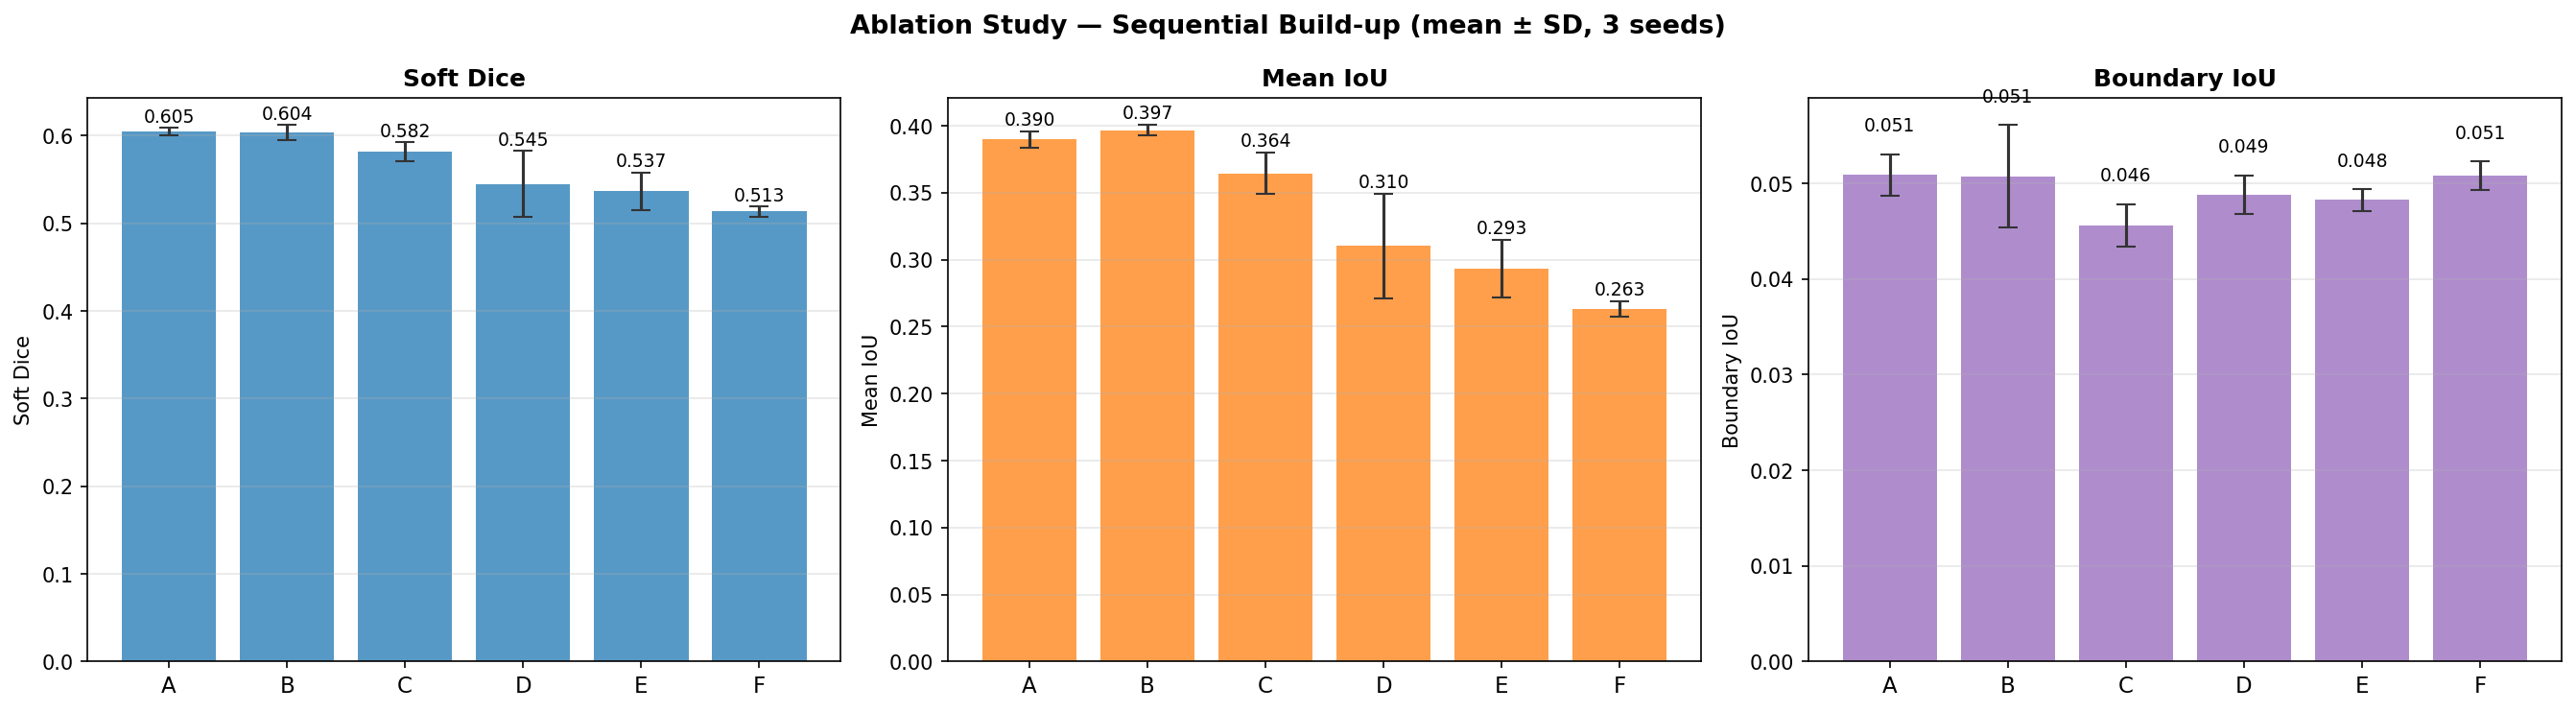

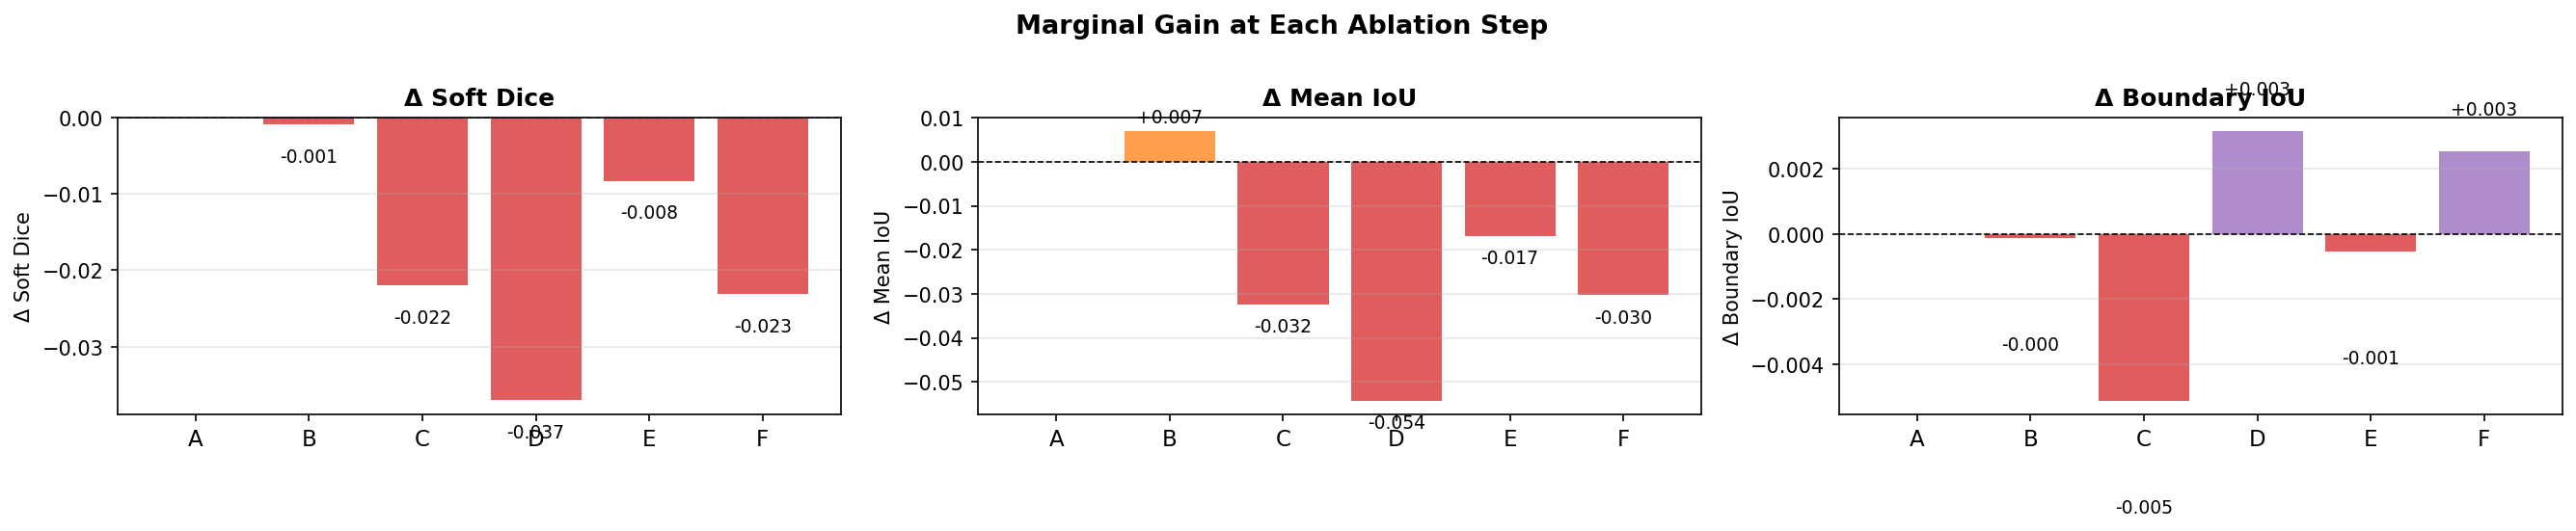

In [61]:
# ── Bar chart with error bars ─────────────────────────────────────────────────
def plot_ablation_bars(df):
    short = [r.split(':')[0] for r in df['Config']]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)
    fig.suptitle(f'Ablation Study — Sequential Build-up'
                 f' (mean ± SD, {len(ABLATION_SEEDS)} seeds)', fontsize=13, fontweight='bold')
    for ax, (mcol, scol, title, color) in zip(axes, [
            ('Dice mu', 'Dice sd', 'Soft Dice',    '#1f77b4'),
            ('mIoU mu', 'mIoU sd', 'Mean IoU',     '#ff7f0e'),
            ('bIoU mu', 'bIoU sd', 'Boundary IoU', '#9467bd')]):
        means, sds = df[mcol].values, df[scol].values
        x = np.arange(len(short))
        bars = ax.bar(x, means, yerr=sds, capsize=5, color=color, alpha=0.75,
                      error_kw=dict(elinewidth=1.5, ecolor='#333'))
        ax.set_xticks(x); ax.set_xticklabels(short, fontsize=11)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(title)
        ax.grid(axis='y', alpha=0.3)
        for bar, m, s in zip(bars, means, sds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.002,
                    f'{m:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('ablation_results/ablation_bars.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close()

def plot_ablation_deltas(df):
    short = [r.split(':')[0] for r in df['Config']]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=150)
    fig.suptitle('Marginal Gain at Each Ablation Step', fontsize=13, fontweight='bold')
    for ax, (mcol, title, color) in zip(axes, [
            ('Dice mu', 'Soft Dice',    '#1f77b4'),
            ('mIoU mu', 'Mean IoU',     '#ff7f0e'),
            ('bIoU mu', 'Boundary IoU', '#9467bd')]):
        vals   = df[mcol].values
        deltas = np.concatenate([[0], np.diff(vals)])
        x      = np.arange(len(short))
        ax.bar(x, deltas, color=[color if d >= 0 else '#d62728' for d in deltas], alpha=0.75)
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_xticks(x); ax.set_xticklabels(short, fontsize=11)
        ax.set_title(f'Δ {title}', fontweight='bold'); ax.set_ylabel(f'Δ {title}')
        ax.grid(axis='y', alpha=0.3)
        for i, d in zip(x, deltas):
            if d != 0:
                ax.text(i, d + (0.001 if d > 0 else -0.003), f'{d:+.3f}',
                        ha='center', va='bottom' if d > 0 else 'top', fontsize=9)
    plt.tight_layout()
    plt.savefig('ablation_results/ablation_deltas.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close()

plot_ablation_bars(ablation_df)
plot_ablation_deltas(ablation_df)

In [62]:
# ── Save CSVs ────────────────────────────────────────────────────────────────
ablation_df.to_csv('ablation_results/ablation_summary.csv', index=False, float_format='%.4f')
raw = [{'config': k, **r} for k, sr in ablation_all_results.items() for r in sr]
pd.DataFrame(raw).to_csv('ablation_results/ablation_per_seed.csv', index=False, float_format='%.4f')
print("CSVs saved to ablation_results/")

CSVs saved to ablation_results/


In [63]:
# LaTeX table for manuscript (paste directly)
lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
n_seeds = len(ABLATION_SEEDS)
lines.append(r"\caption{Ablation study: sequential build-up results (mean $\pm$ SD, " + str(n_seeds) + r" seeds).}")
lines.append(r"\label{tab:ablation}")
lines.append(r"\begin{tabular}{llccc}")
lines.append(r"\hline")
lines.append(r"Config & Description & Soft Dice & Mean IoU & Boundary IoU \\")
lines.append(r"\hline")
for _, row in ablation_df.iterrows():
    cfg  = row['Config']
    desc = row['Description']
    d    = f"${row['Dice mu']:.3f}\\pm{row['Dice sd']:.3f}$"
    mi   = f"${row['mIoU mu']:.3f}\\pm{row['mIoU sd']:.3f}$"
    bi   = f"${row['bIoU mu']:.3f}\\pm{row['bIoU sd']:.3f}$"
    lines.append(f"{cfg} & {desc} & {d} & {mi} & {bi} \\\\")
lines.append(r"\hline")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
print("\n".join(lines))


\begin{table}[ht]
\centering
\caption{Ablation study: sequential build-up results (mean $\pm$ SD, 3 seeds).}
\label{tab:ablation}
\begin{tabular}{llccc}
\hline
Config & Description & Soft Dice & Mean IoU & Boundary IoU \\
\hline
A: Plain 3D U-Net & No residual, no SE, Dice+BCE, uniform sampling & $0.605\pm0.004$ & $0.390\pm0.006$ & $0.051\pm0.002$ \\
B: 3D ResUNet (no SE) & + Residual bottleneck blocks, Dice+BCE, uniform sampling & $0.604\pm0.009$ & $0.397\pm0.004$ & $0.051\pm0.005$ \\
C: 3D SE-ResUNet & + Squeeze-and-Excitation blocks, Dice+BCE, uniform sampling & $0.582\pm0.011$ & $0.364\pm0.015$ & $0.046\pm0.002$ \\
D: SE-ResUNet + Composite Loss & + 4-term boundary-focused composite loss, uniform sampling & $0.545\pm0.038$ & $0.310\pm0.039$ & $0.049\pm0.002$ \\
E: Full SE-ResUNet + Depth-Stratified & + Geology-aware depth-stratified sampling & $0.537\pm0.022$ & $0.293\pm0.021$ & $0.048\pm0.001$ \\
F: Full Model + Depth-Bin-Weighted Loss & + Per-depth-bin loss weighting (D0=0.5, D1=

<!-- ## 8. Perturbation Experiments

All perturbation models start from the **Config E weights** (full base model, best seed=42 checkpoint) via transfer learning and are evaluated on the same 101-patch validation set.
### Perturbation parameters (explicit, for reproducibility)

| Parameter | Value |
|---|---|
| Seismic perturbation probability | D0: 0.75, D1: 0.50, D2: 0.25 |
| Gain range | [0.2, 2.0] |
| Additive noise (fraction of data std) | [0.15, 0.40] |
| Sinusoidal artefact strength | [0.05, 0.15]; frequency [1–4] cycles |
| 3-D blur kernel | 3×3×3 box, 50 % application probability |
| Label perturbation probability | D0: 0.20, D1: 0.40, D2: 0.60 |
| Gaussian blur sigma | [1.0, 2.0] |
| Erosion/dilation probability | 0.30 |
| Erosion/dilation iterations | 1 | -->

In [ ]:
# # ── Seismic perturbation generator ───────────────────────────────────────────
# def seismic_perturbation_gen(data_gen, perturbation_prob=0.75):
#     """Stratified seismic perturbation applied to D0 (shallow) patches only.
#     Higher probability for shallow data avoids compounding synthetic noise
#     on already-degraded deep imaging (see Section 3.6)."""
#     while True:
#         for batch_data, batch_mask, depth_labels in data_gen:
#             orig   = tf.convert_to_tensor(batch_data, dtype=tf.float32)
#             bs     = tf.shape(orig)[0]
#             dlabels = tf.squeeze(tf.convert_to_tensor(depth_labels), axis=-1) \
#                       if len(tf.convert_to_tensor(depth_labels).shape) > 1 \
#                       else tf.convert_to_tensor(depth_labels)
#             is_d0   = tf.equal(dlabels, 0)
#             pmask   = tf.random.uniform([bs,1,1,1,1]) < perturbation_prob
#             fmask   = tf.logical_and(is_d0[:,None,None,None,None], pmask)
#             aug     = orig
#             # 1. Gain perturbation
#             aug = aug * tf.random.uniform([bs,1,1,1,1], 0.2, 2.0)
#             # 2. Additive noise
#             std  = tf.math.reduce_std(aug)
#             ns   = tf.random.uniform([bs], 0.15, 0.40) * std
#             aug  = aug + tf.random.normal(tf.shape(aug), 0.0,
#                          ns[:,None,None,None,None])
#             # 3. Sinusoidal migration artefact
#             s_str = tf.random.uniform([bs,1,1,1,1], 0.05, 0.15)
#             tdim  = tf.shape(aug)[1]
#             freq  = tf.random.uniform([], 1.0, 4.0) * np.pi
#             t     = tf.linspace(0.0, freq, tdim)
#             ph    = tf.random.uniform([bs], 0.0, 2*np.pi)
#             wave  = s_str * tf.sin(t[None,:,None,None,None] + ph[:,None,None,None,None])
#             aug   = aug + wave
#             # 4. Spectral blur (50 % chance)
#             blur_k = tf.ones((3,3,3,1,1)) / 27.0
#             blurred = tf.nn.conv3d(aug, blur_k, strides=[1,1,1,1,1], padding='SAME')
#             do_blur = tf.random.uniform([bs,1,1,1,1]) < 0.5
#             aug     = tf.where(do_blur, blurred, aug)
#             # 5. Clip
#             aug = tf.clip_by_value(aug, -1.5, 1.5)
#             yield tf.where(fmask, aug, orig).numpy(), batch_mask, depth_labels
#         data_gen.on_epoch_end()


# # ── Label perturbation generator ─────────────────────────────────────────────
# def label_perturbation_gen(data_gen, perturbation_prob=0.5):
#     """Depth-stratified label noise: higher perturbation rate for deeper patches
#     where velocity-derived masks carry greater interpretation uncertainty.
#     Probabilities: D0=0.20, D1=0.40, D2=0.60 (scaled by perturbation_prob)."""
#     depth_probs = {0: 0.20, 1: 0.40, 2: 0.60}
#     while True:
#         for batch_data, batch_mask, depth_labels in data_gen:
#             pm = batch_mask.copy().astype(np.float32)
#             for i in range(pm.shape[0]):
#                 d_prob = depth_probs.get(depth_labels[i] if isinstance(depth_labels, list)
#                                          else int(depth_labels[i]), 0.4)
#                 if np.random.rand() < d_prob * (perturbation_prob / 0.5):
#                     has_ch = pm.ndim == 5
#                     ms = pm[i,...,0] if has_ch else pm[i]
#                     # 1. Gaussian blur
#                     ms = gaussian_filter(ms, sigma=np.random.uniform(1.0, 2.0))
#                     # 2. Erosion / dilation (30 % chance)
#                     if np.random.rand() < 0.30 and 0.01 < np.mean(ms) < 0.99:
#                         bm = ms > 0.5
#                         bm = (binary_erosion(bm, iterations=1)
#                               if np.random.rand() > 0.5
#                               else binary_dilation(bm, iterations=1))
#                         ms = gaussian_filter(bm.astype(np.float32), sigma=0.5)
#                     if has_ch: pm[i,...,0] = np.clip(ms, 0, 1)
#                     else:      pm[i]       = np.clip(ms, 0, 1)
#             yield batch_data, pm, depth_labels
#         if hasattr(data_gen, 'on_epoch_end'):
#             data_gen.on_epoch_end()

# print("Perturbation generators defined.")

Perturbation generators defined.


<!-- ### 8.1 Shared callback builder for perturbation models -->

In [ ]:
# def make_perturb_callbacks(name, vl_gen):
#     return [
#         ModelCheckpoint(f'{name}_best_biou.h5', monitor='val_boundary_iou',
#                         save_best_only=True, mode='max', verbose=1),
#         ModelCheckpoint(f'{name}_best_dice.h5', monitor='val_soft_dice_coef',
#                         save_best_only=True, mode='max', verbose=1),
#         EarlyStopping(monitor='val_soft_dice_coef', mode='max',
#                       patience=10, restore_best_weights=True, verbose=1),
#         ReduceLROnPlateau(monitor='val_soft_dice_coef', mode='max',
#                           factor=0.5, patience=5, min_lr=1e-7, verbose=1),
#         DepthStratifiedMetrics(val_gen=vl_gen, boundary_width=2),
#     ]

# def plot_training_curves(history, title):
#     fig, axes = plt.subplots(1, 4, figsize=(24, 5), dpi=150)
#     fig.suptitle(title, fontsize=13, fontweight='bold')
#     for ax, (key, label, color) in zip(axes[:3], [
#             ('soft_dice_coef', 'Soft Dice',    '#1f77b4'),
#             ('mean_iou',       'Mean IoU',      '#ff7f0e'),
#             ('boundary_iou',   'Boundary IoU',  '#9467bd')]):
#         best_ep = int(np.argmax(history.history[f'val_{key}']))
#         best_v  = history.history[f'val_{key}'][best_ep]
#         ax.plot(history.history[key],         label='Train', color=color, lw=2.5)
#         ax.plot(history.history[f'val_{key}'], label='Val',   color=color, lw=2.5, alpha=0.6)
#         ax.scatter(best_ep, best_v, color='#2ca02c', zorder=5, s=60)
#         ax.text(best_ep+0.5, best_v, f'{best_v:.3f}', fontsize=10,
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
#         ax.set_title(label, fontweight='bold'); ax.set_ylabel(label)
#         ax.set_xlabel('Epoch'); ax.legend(frameon=False); ax.grid(True, alpha=0.3)
#     axes[3].plot(history.history['loss'],     label='Train', color='#1f77b4', lw=2.5)
#     axes[3].plot(history.history['val_loss'], label='Val',   color='#d62728', lw=2.5)
#     axes[3].set_title('Loss', fontweight='bold'); axes[3].set_xlabel('Epoch')
#     axes[3].legend(frameon=False); axes[3].grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(f'{title.lower().replace(" ","_")}_curves.png', dpi=150,
#                 bbox_inches='tight', facecolor='white')
#     plt.show(); plt.close()

# def plot_depth_metrics(callback, title=''):
#     epochs = range(1, len(callback.dice_history['0']) + 1)
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
#     for ax, hist, ylabel in [(ax1, callback.dice_history, 'Soft Dice'),
#                               (ax2, callback.biou_history, 'Boundary IoU')]:
#         for key, label, marker in [('0','Shallow (D0)','o'), ('1','Mid (D1)','s'), ('2','Deep (D2)','^')]:
#             if hist[key]:
#                 ax.plot(epochs, hist[key], f'{marker}-', label=label, lw=2, ms=6)
#         ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
#         ax.set_title(f'Depth-Stratified {ylabel} — {title}')
#         ax.legend(); ax.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(f'depth_metrics_{title.lower().replace(" ","_")}.png',
#                 dpi=150, bbox_inches='tight')
#     plt.show(); plt.close()

# print("Callback and plot helpers defined.")

Callback and plot helpers defined.


<!-- ### 8.2 Base Model (Config E — seed 42) -->

In [ ]:
# # The base model is Config E trained with seed=42.
# # Rebuild generators with the same settings for consistency.
# train_gen, val_gen = build_generators(X_train, y_train, X_val, y_val,
#                                       train_seed=42, val_seed=VAL_SEED, depth_stratified=True)

# tf.keras.backend.clear_session()
# base_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
# base_callbacks = make_perturb_callbacks('base_model', val_gen)

# base_history = base_model.fit(
#     train_gen, validation_data=val_gen,
#     epochs=75,
#     callbacks=base_callbacks, verbose=1,
# )
# base_model.save('models/base_model_final.h5')
# print("✅ Base model trained and saved.")

  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 365  (depth_stratified=True, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)
Epoch 1/75
91/91 [==============================] - ETA: 0s - loss: 1.1334 - soft_dice_coef: 0.3885 - mean_iou: 0.1181 - boundary_iou: 0.0353 - distance_weighted_bce: 0.6659 - boundary_dice_loss: 0.9323
Epoch 1: val_boundary_iou improved from -inf to 0.05516, saving model to bas

KeyboardInterrupt: 

In [ ]:
# plot_training_curves(base_history, 'Base Model')
# plot_depth_metrics(base_callbacks[-1], 'Base Model')

<!-- ### 8.3 Seismic-Perturbed Model -->

In [ ]:
# tf.keras.backend.clear_session()
# seismic_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
# seismic_model.load_weights('base_model_best_dice.h5')
# seismic_callbacks = make_perturb_callbacks('seismic_model', val_gen)

# seismic_history = seismic_model.fit(
#     seismic_perturbation_gen(train_gen, perturbation_prob=0.75),
#     validation_data=val_gen,
#     epochs=75, 
#     callbacks=seismic_callbacks, verbose=1,
# )
# seismic_model.save('models/seismic_model_final.h5')
# print("✅ Seismic-perturbed model trained and saved.")

In [ ]:
# plot_training_curves(seismic_history, 'Seismic Perturbation')
# plot_depth_metrics(seismic_callbacks[-1], 'Seismic Perturbation')

<!-- ### 8.4 Label-Perturbed Model -->

In [ ]:
# tf.keras.backend.clear_session()
# label_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
# label_model.load_weights('base_model_best_dice.h5')
# label_callbacks = make_perturb_callbacks('label_model', val_gen)

# label_history = label_model.fit(
#     label_perturbation_gen(train_gen, perturbation_prob=0.50),
#     validation_data=val_gen,
#     epochs=75, 
#     callbacks=label_callbacks, verbose=1,
# )
# label_model.save('models/label_model_final.h5')
# print("✅ Label-perturbed model trained and saved.")

In [ ]:
# plot_training_curves(label_history, 'Label Perturbation')
# plot_depth_metrics(label_callbacks[-1], 'Label Perturbation')

<!-- ### 8.5 Joint Seismic + Label Perturbation Model -->

In [ ]:
# tf.keras.backend.clear_session()
# joint_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
# joint_model.load_weights('base_model_best_dice.h5')
# joint_callbacks = make_perturb_callbacks('joint_model', val_gen)

# joint_history = joint_model.fit(
#     seismic_perturbation_gen(
#         label_perturbation_gen(train_gen, perturbation_prob=0.50),
#         perturbation_prob=0.50),
#     validation_data=val_gen,
#     epochs=75, 
#     callbacks=joint_callbacks, verbose=1,
# )
# joint_model.save('models/joint_model_final.h5')
# print("✅ Joint perturbation model trained and saved.")

In [ ]:
# plot_training_curves(joint_history, 'Joint Perturbation')
# plot_depth_metrics(joint_callbacks[-1], 'Joint Perturbation')

<!-- ## 9. Perturbation Results — Quantitative Summary

All metrics are extracted from the **single best checkpoint** (monitored by `val_soft_dice_coef`) for each model, ensuring no optimistic multi-checkpoint reporting. -->

In [ ]:
# def best_from_history(h, name):
#     ep = int(np.argmax(h.history['val_soft_dice_coef']))
#     return {'Model': name,
#             'Best epoch': ep + 1,
#             'Dice':         round(h.history['val_soft_dice_coef'][ep], 4),
#             'Mean IoU':     round(h.history['val_mean_iou'][ep],       4),
#             'Boundary IoU': round(h.history['val_boundary_iou'][ep],   4)}

# perturb_rows = [
#     best_from_history(base_history,    'Base model'),
#     best_from_history(seismic_history, 'Seismic perturbed'),
#     best_from_history(label_history,   'Label perturbed'),
#     best_from_history(joint_history,   'Joint (seismic + label)'),
# ]
# perturb_df = pd.DataFrame(perturb_rows)
# display(perturb_df)

# # Save to CSV
# perturb_df.to_csv('models/perturbation_summary.csv', index=False)
# print("Saved: models/perturbation_summary.csv")

In [ ]:
# # Grouped bar chart — perturbation comparison
# fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)
# fig.suptitle('Effect of Data Perturbation on Salt Segmentation Metrics',
#              fontsize=13, fontweight='bold')
# models = perturb_df['Model'].tolist()
# x      = np.arange(len(models))
# w      = 0.6
# for ax, (col, title, color) in zip(axes, [
#         ('Dice',         'Soft Dice',    '#1f77b4'),
#         ('Mean IoU',     'Mean IoU',     '#ff7f0e'),
#         ('Boundary IoU', 'Boundary IoU', '#9467bd')]):
#     bars = ax.bar(x, perturb_df[col], width=w, color=color, alpha=0.78)
#     ax.set_xticks(x)
#     ax.set_xticklabels(['Base', 'Seismic', 'Label', 'Joint'], fontsize=10)
#     ax.set_title(title, fontweight='bold'); ax.set_ylabel(title)
#     ax.set_ylim(perturb_df[col].min() * 0.97, perturb_df[col].max() * 1.02)
#     ax.grid(axis='y', alpha=0.3)
#     for bar, v in zip(bars, perturb_df[col]):
#         ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
#                 f'{v:.3f}', ha='center', va='bottom', fontsize=10)
# plt.tight_layout()
# plt.savefig('models/perturbation_comparison.png', dpi=150,
#             bbox_inches='tight', facecolor='white')
# plt.show(); plt.close()

<!-- ## 10. Ensemble Prediction & Quantitative Evaluation

The four models are averaged to produce the final salt probability volume. Ensemble metrics are computed on the same 101-patch validation set and added to the summary table. -->

In [ ]:
# # ── Load best checkpoints ────────────────────────────────────────────────────
# tf.keras.backend.clear_session()
# ens_models = []
# for name, ckpt in [('base',    'base_model_best_dice.h5'),
#                    ('seismic', 'seismic_model_best_dice.h5'),
#                    ('label',   'label_model_best_dice.h5'),
#                    ('joint',   'joint_model_best_dice.h5')]:
#     m = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss)
#     m.load_weights(ckpt)
#     ens_models.append(m)
#     print(f"  Loaded: {ckpt}")

# # Binarisation threshold (reported explicitly per reviewer request)
# THRESHOLD = 0.50
# print(f"\nBinarisation threshold: {THRESHOLD}")

In [ ]:
# # ── Compute ensemble metrics on the validation set ───────────────────────────
# ens_dice_list, ens_miou_list, ens_biou_list = [], [], []

# for i in range(len(val_gen)):
#     Xv, yt, _ = val_gen[i]
#     # Average probabilities across the four models
#     avg_prob = np.mean([m.predict(Xv, verbose=0) for m in ens_models], axis=0)
#     yp_bin   = (avg_prob > THRESHOLD).astype(np.float32)

#     for j in range(len(Xv)):
#         yt_ = np.squeeze(yt[j])
#         yps = np.squeeze(avg_prob[j])
#         ypb = np.squeeze(yp_bin[j])
#         inter  = np.sum(yt_ * yps)
#         usq    = np.sum(np.square(yt_)) + np.sum(np.square(yps))
#         dice   = (2 * inter + 1e-6) / (usq + 1e-6)
#         miou_i = (np.sum(yt_ * ypb) + 1e-6) / (np.sum(yt_) + np.sum(ypb) - np.sum(yt_*ypb) + 1e-6)
#         biou_i = numpy_boundary_iou(yt_, ypb, bw=2)
#         ens_dice_list.append(dice)
#         ens_miou_list.append(miou_i)
#         ens_biou_list.append(biou_i)

# ens_row = {'Model': 'Ensemble (avg)',
#            'Best epoch': '—',
#            'Dice':         round(np.mean(ens_dice_list), 4),
#            'Mean IoU':     round(np.mean(ens_miou_list), 4),
#            'Boundary IoU': round(np.mean(ens_biou_list), 4)}

# full_df = pd.concat([perturb_df, pd.DataFrame([ens_row])], ignore_index=True)
# display(full_df)
# full_df.to_csv('models/full_results_with_ensemble.csv', index=False)
# print("\nSaved: models/full_results_with_ensemble.csv")

<!-- ## 11. Combined Results Tables for Manuscript -->

In [ ]:
# print("=" * 60)
# print("TABLE 3 — Perturbation Experiment Results")
# print("=" * 60)
# print(full_df[['Model','Dice','Mean IoU','Boundary IoU']].to_string(index=False))

# print("\n" + "=" * 60)
# print("TABLE 4 — Ablation Study Results")
# print("=" * 60)
# abl_display = ablation_df[['Config','Dice mu','Dice sd','mIoU mu','mIoU sd','bIoU mu','bIoU sd']].copy()
# abl_display['Soft Dice']    = abl_display.apply(lambda r: f"{r['Dice mu']:.3f}±{r['Dice sd']:.3f}", axis=1)
# abl_display['Mean IoU']     = abl_display.apply(lambda r: f"{r['mIoU mu']:.3f}±{r['mIoU sd']:.3f}", axis=1)
# abl_display['Boundary IoU'] = abl_display.apply(lambda r: f"{r['bIoU mu']:.3f}±{r['bIoU sd']:.3f}", axis=1)
# print(abl_display[['Config','Soft Dice','Mean IoU','Boundary IoU']].to_string(index=False))

## 8. Perturbation Experiments

All perturbation models start from the **Config E weights** (full base model, best seed=42 checkpoint) via transfer learning and are evaluated on the same 101-patch validation set.
### Perturbation parameters (explicit, for reproducibility)

| Parameter | Value |
|---|---|
| Seismic perturbation probability | D0: 0.75, D1: 0.50, D2: 0.25 |
| Gain range | [0.2, 2.0] |
| Additive noise (fraction of data std) | [0.15, 0.40] |
| Sinusoidal artefact strength | [0.05, 0.15]; frequency [1–4] cycles |
| 3-D blur kernel | 3×3×3 box, 50 % application probability |
| Label perturbation probability | D0: 0.20, D1: 0.40, D2: 0.60 |
| Gaussian blur sigma | [1.0, 2.0] |
| Erosion/dilation probability | 0.30 |
| Erosion/dilation iterations | 1 |

In [70]:
# ── Seismic perturbation generator ───────────────────────────────────────────
def seismic_perturbation_gen(data_gen, perturbation_prob=0.75):
    """Stratified seismic perturbation applied to D0 (shallow) patches only.
    Higher probability for shallow data avoids compounding synthetic noise
    on already-degraded deep imaging (see Section 3.6)."""
    while True:
        for batch_data, batch_mask, depth_labels in data_gen:
            orig   = tf.convert_to_tensor(batch_data, dtype=tf.float32)
            bs     = tf.shape(orig)[0]
            dlabels = tf.squeeze(tf.convert_to_tensor(depth_labels), axis=-1) \
                      if len(tf.convert_to_tensor(depth_labels).shape) > 1 \
                      else tf.convert_to_tensor(depth_labels)
            is_d0   = tf.equal(dlabels, 0)
            pmask   = tf.random.uniform([bs,1,1,1,1]) < perturbation_prob
            fmask   = tf.logical_and(is_d0[:,None,None,None,None], pmask)
            aug     = orig
            # 1. Gain perturbation
            aug = aug * tf.random.uniform([bs,1,1,1,1], 0.2, 2.0)
            # 2. Additive noise
            std  = tf.math.reduce_std(aug)
            ns   = tf.random.uniform([bs], 0.15, 0.40) * std
            aug  = aug + tf.random.normal(tf.shape(aug), 0.0,
                         ns[:,None,None,None,None])
            # 3. Sinusoidal migration artefact
            s_str = tf.random.uniform([bs,1,1,1,1], 0.05, 0.15)
            tdim  = tf.shape(aug)[1]
            freq  = tf.random.uniform([], 1.0, 4.0) * np.pi
            t     = tf.linspace(0.0, freq, tdim)
            ph    = tf.random.uniform([bs], 0.0, 2*np.pi)
            wave  = s_str * tf.sin(t[None,:,None,None,None] + ph[:,None,None,None,None])
            aug   = aug + wave
            # 4. Spectral blur (50 % chance)
            blur_k = tf.ones((3,3,3,1,1)) / 27.0
            blurred = tf.nn.conv3d(aug, blur_k, strides=[1,1,1,1,1], padding='SAME')
            do_blur = tf.random.uniform([bs,1,1,1,1]) < 0.5
            aug     = tf.where(do_blur, blurred, aug)
            # 5. Clip
            aug = tf.clip_by_value(aug, -1.5, 1.5)
            yield tf.where(fmask, aug, orig).numpy(), batch_mask, depth_labels
        data_gen.on_epoch_end()


# ── Label perturbation generator ─────────────────────────────────────────────
def label_perturbation_gen(data_gen, perturbation_prob=0.5):
    """Depth-stratified label noise: higher perturbation rate for deeper patches
    where velocity-derived masks carry greater interpretation uncertainty.
    Probabilities: D0=0.20, D1=0.40, D2=0.60 (scaled by perturbation_prob)."""
    depth_probs = {0: 0.20, 1: 0.40, 2: 0.60}
    while True:
        for batch_data, batch_mask, depth_labels in data_gen:
            pm = batch_mask.copy().astype(np.float32)
            for i in range(pm.shape[0]):
                d_prob = depth_probs.get(depth_labels[i] if isinstance(depth_labels, list)
                                         else int(depth_labels[i]), 0.4)
                if np.random.rand() < d_prob * (perturbation_prob / 0.5):
                    has_ch = pm.ndim == 5
                    ms = pm[i,...,0] if has_ch else pm[i]
                    # 1. Gaussian blur
                    ms = gaussian_filter(ms, sigma=np.random.uniform(1.0, 2.0))
                    # 2. Erosion / dilation (30 % chance)
                    if np.random.rand() < 0.30 and 0.01 < np.mean(ms) < 0.99:
                        bm = ms > 0.5
                        bm = (binary_erosion(bm, iterations=1)
                              if np.random.rand() > 0.5
                              else binary_dilation(bm, iterations=1))
                        ms = gaussian_filter(bm.astype(np.float32), sigma=0.5)
                    if has_ch: pm[i,...,0] = np.clip(ms, 0, 1)
                    else:      pm[i]       = np.clip(ms, 0, 1)
            yield batch_data, pm, depth_labels
        if hasattr(data_gen, 'on_epoch_end'):
            data_gen.on_epoch_end()

print("Perturbation generators defined.")

Perturbation generators defined.


### 8.1 Shared callback builder for perturbation models

In [71]:
def make_perturb_callbacks(name, vl_gen):
    return [
        ModelCheckpoint(f'{name}_best_biou.h5', monitor='val_boundary_iou',
                        save_best_only=True, mode='max', verbose=1),
        ModelCheckpoint(f'{name}_best_dice.h5', monitor='val_soft_dice_coef',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_soft_dice_coef', mode='max',
                      patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_soft_dice_coef', mode='max',
                          factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        DepthStratifiedMetrics(val_gen=vl_gen, boundary_width=2),
    ]

def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 4, figsize=(24, 5), dpi=150)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (key, label, color) in zip(axes[:3], [
            ('soft_dice_coef', 'Soft Dice',    '#1f77b4'),
            ('mean_iou',       'Mean IoU',      '#ff7f0e'),
            ('boundary_iou',   'Boundary IoU',  '#9467bd')]):
        best_ep = int(np.argmax(history.history[f'val_{key}']))
        best_v  = history.history[f'val_{key}'][best_ep]
        ax.plot(history.history[key],         label='Train', color=color, lw=2.5)
        ax.plot(history.history[f'val_{key}'], label='Val',   color=color, lw=2.5, alpha=0.6)
        ax.scatter(best_ep, best_v, color='#2ca02c', zorder=5, s=60)
        ax.text(best_ep+0.5, best_v, f'{best_v:.3f}', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
        ax.set_title(label, fontweight='bold'); ax.set_ylabel(label)
        ax.set_xlabel('Epoch'); ax.legend(frameon=False); ax.grid(True, alpha=0.3)
    axes[3].plot(history.history['loss'],     label='Train', color='#1f77b4', lw=2.5)
    axes[3].plot(history.history['val_loss'], label='Val',   color='#d62728', lw=2.5)
    axes[3].set_title('Loss', fontweight='bold'); axes[3].set_xlabel('Epoch')
    axes[3].legend(frameon=False); axes[3].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_curves.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show(); plt.close()

def plot_depth_metrics(callback, title=''):
    epochs = range(1, len(callback.dice_history['0']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    for ax, hist, ylabel in [(ax1, callback.dice_history, 'Soft Dice'),
                              (ax2, callback.biou_history, 'Boundary IoU')]:
        for key, label, marker in [('0','Shallow (D0)','o'), ('1','Mid (D1)','s'), ('2','Deep (D2)','^')]:
            if hist[key]:
                ax.plot(epochs, hist[key], f'{marker}-', label=label, lw=2, ms=6)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(f'Depth-Stratified {ylabel} — {title}')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'depth_metrics_{title.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

print("Callback and plot helpers defined.")

Callback and plot helpers defined.


### 8.2 Base Model (Config E — seed 42)

In [72]:
# The base model is Config E trained with seed=42.
# Rebuild generators with the same settings for consistency.
train_gen, val_gen = build_generators(X_train, y_train, X_val, y_val,
                                      train_seed=42, val_seed=VAL_SEED,
                                      depth_stratified=True)

tf.keras.backend.clear_session()
base_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
base_callbacks = make_perturb_callbacks('base_model', val_gen)

base_history = base_model.fit(
    train_gen, validation_data=val_gen,
    epochs=75,
    callbacks=base_callbacks, verbose=1,
)
base_model.save('models/base_model_final.h5')
print("✅ Base model trained and saved.")

  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 72 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  1944 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 861  low-fg: 127  high-fg: 93
  Patches selected: 365  (depth_stratified=True, bg_ratio=0.15, max_depth_ft=40000, seed=42)
  Depth cap: 40,000 ft (≈ 1250 depth samples out of 1876)
  Buffer exclusion: 54 patch columns dropped (near-boundary autocorrelation control)
  Depth exclusion:  972 patches dropped (centre depth ≥ 40,000 ft)
  Candidate patches — bg: 858  low-fg: 143  high-fg: 62
  Patches selected: 100  (depth_stratified=False, bg_ratio=0.15, max_depth_ft=40000, seed=999)
Epoch 1/75
91/91 [==============================] - ETA: 0s - loss: 1.1333 - soft_dice_coef: 0.3886 - mean_iou: 0.1183 - boundary_iou: 0.0352 - distance_weighted_bce: 0.6658 - boundary_dice_loss: 0.9323
Epoch 1: val_boundary_iou improved from -inf to 0.05507, saving model to bas

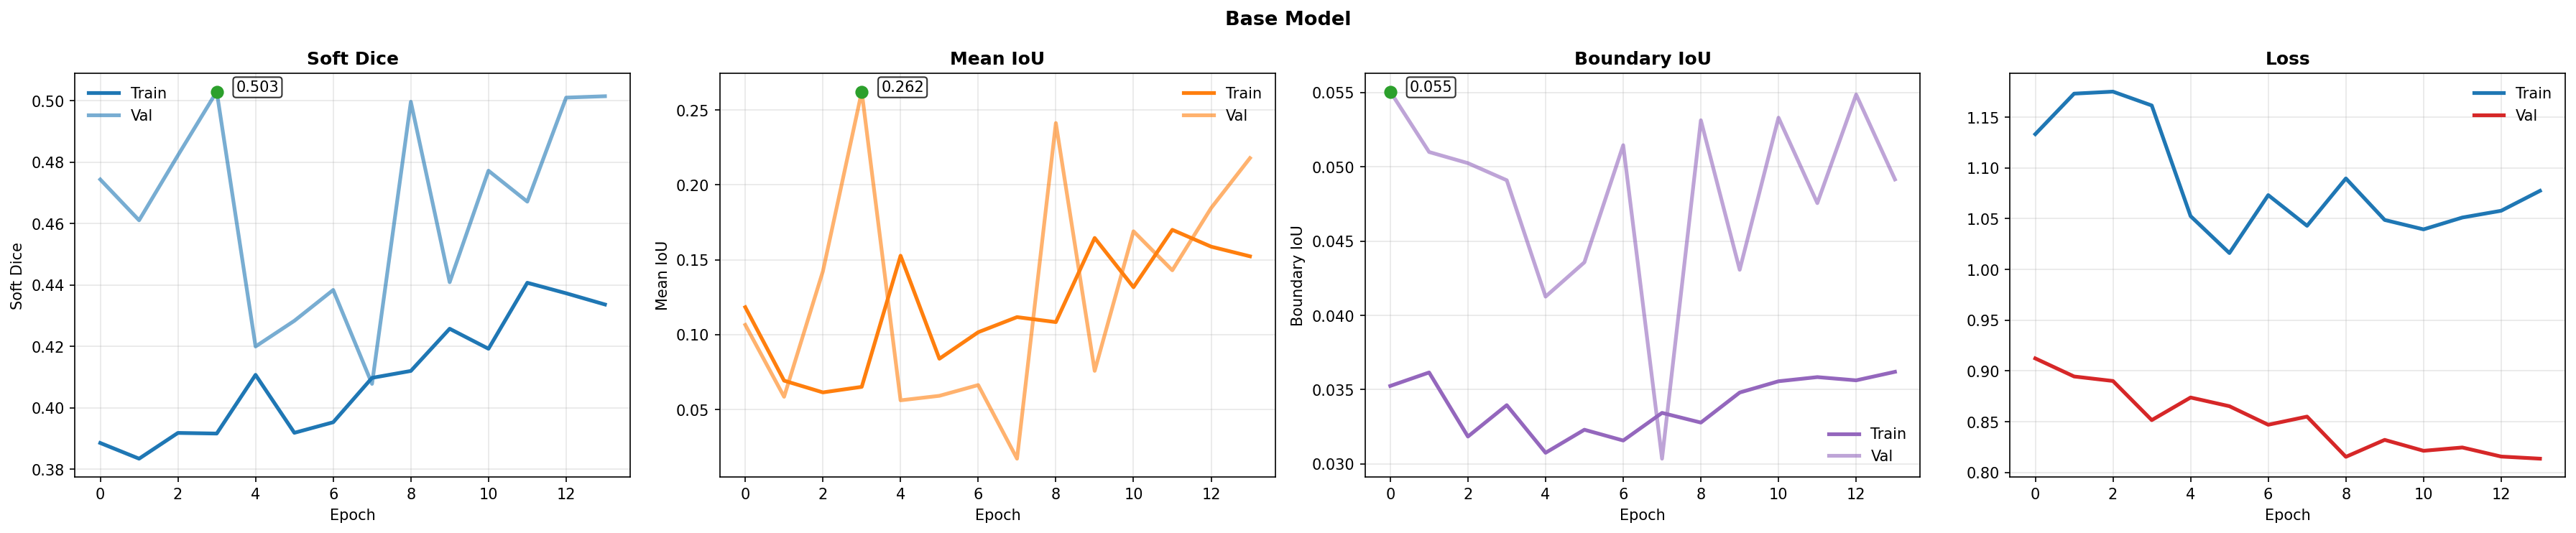

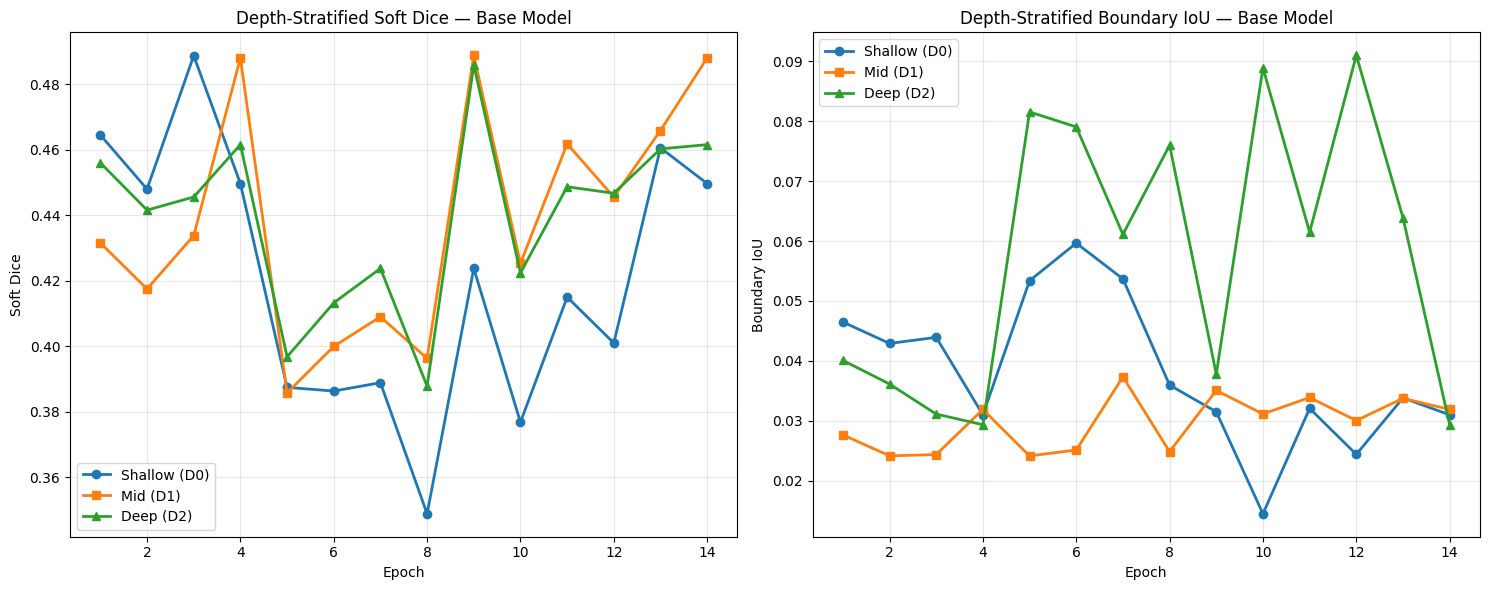

In [73]:
plot_training_curves(base_history, 'Base Model')
plot_depth_metrics(base_callbacks[-1], 'Base Model')

### 8.3 Seismic-Perturbed Model

In [74]:
tf.keras.backend.clear_session()
seismic_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
seismic_model.load_weights('base_model_best_dice.h5')
seismic_callbacks = make_perturb_callbacks('seismic_model', val_gen)

seismic_history = seismic_model.fit(
    seismic_perturbation_gen(train_gen, perturbation_prob=0.75),
    validation_data=val_gen,
    steps_per_epoch=len(train_gen),
    epochs=75,
    callbacks=seismic_callbacks, verbose=1,
)
seismic_model.save('models/seismic_model_final.h5')
print("✅ Seismic-perturbed model trained and saved.")

Epoch 1/75
91/91 [==============================] - ETA: 0s - loss: 1.1308 - soft_dice_coef: 0.3965 - mean_iou: 0.1067 - boundary_iou: 0.0322 - distance_weighted_bce: 0.5094 - boundary_dice_loss: 0.9379
Epoch 1: val_boundary_iou improved from -inf to 0.02626, saving model to seismic_model_best_biou.h5

Epoch 1: val_soft_dice_coef improved from -inf to 0.43750, saving model to seismic_model_best_dice.h5

  [Depth] Epoch 1 | Dice=0.4050 | bIoU=0.0232
    D0: Dice=0.3827±0.170  bIoU=0.0451  (33 patches)
    D1: Dice=0.4223±0.184  bIoU=0.0151  (34 patches)
    D2: Dice=0.4095±0.151  bIoU=0.0098  (33 patches)
91/91 [==============================] - 147s 2s/step - loss: 1.1308 - soft_dice_coef: 0.3965 - mean_iou: 0.1067 - boundary_iou: 0.0322 - distance_weighted_bce: 0.5094 - boundary_dice_loss: 0.9379 - val_loss: 0.8694 - val_soft_dice_coef: 0.4375 - val_mean_iou: 0.0012 - val_boundary_iou: 0.0263 - val_distance_weighted_bce: 0.5729 - val_boundary_dice_loss: 0.9492 - lr: 1.0000e-04
Epoch 2

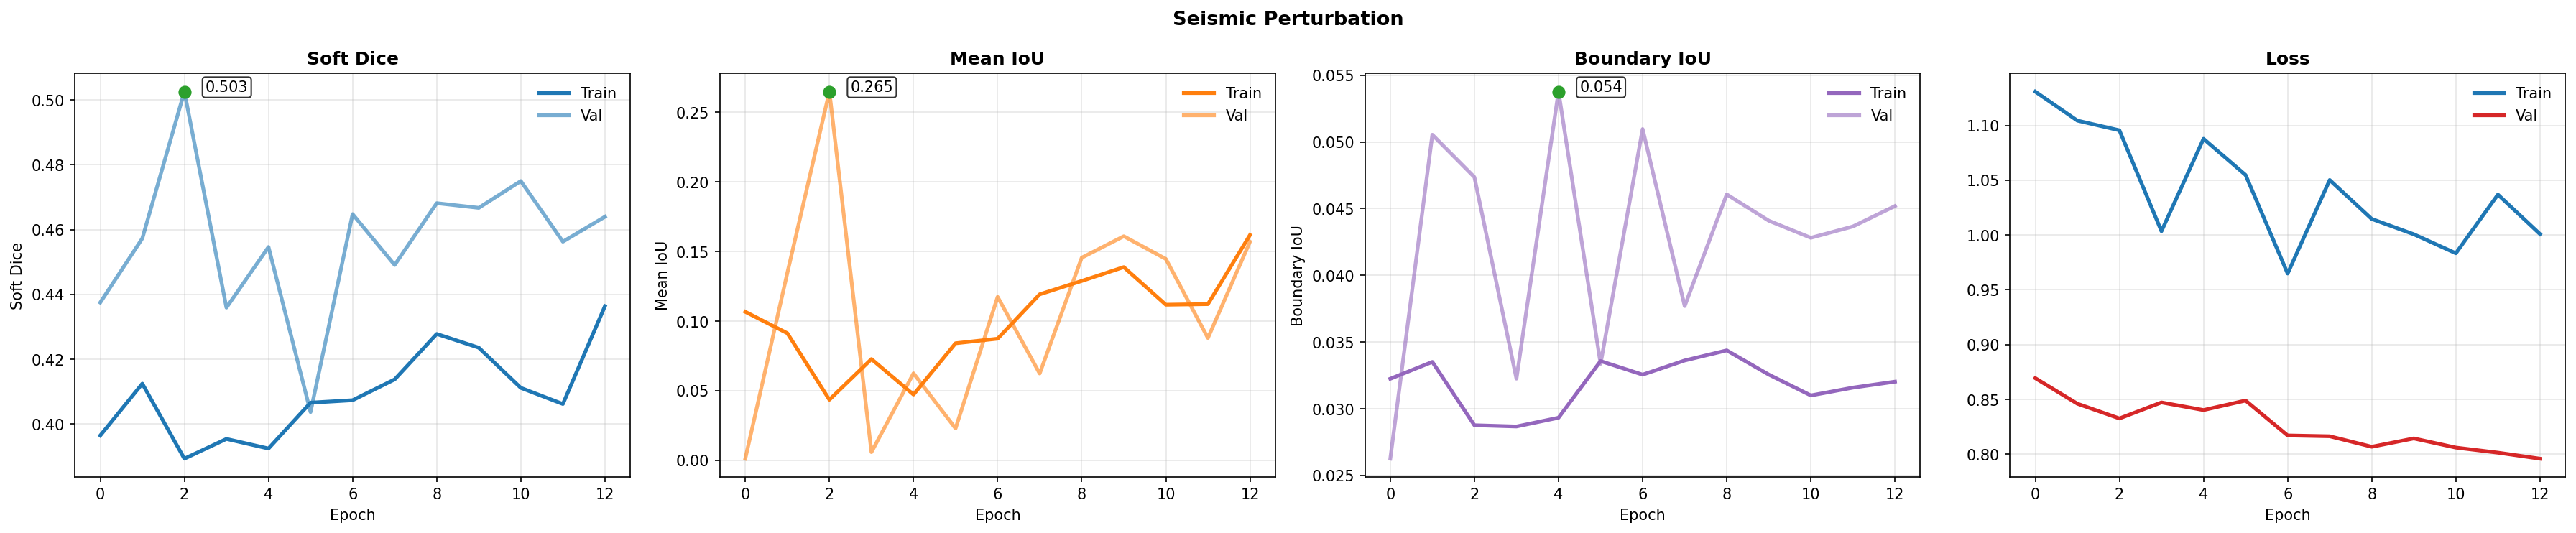

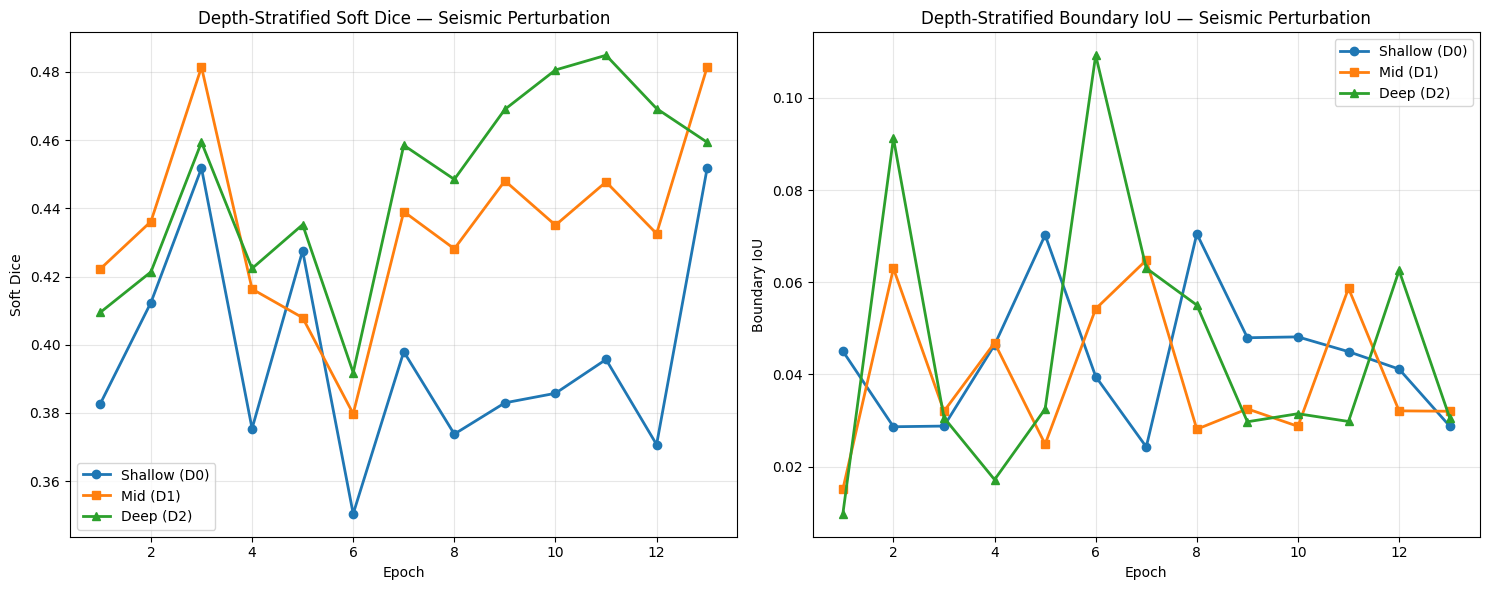

In [75]:
plot_training_curves(seismic_history, 'Seismic Perturbation')
plot_depth_metrics(seismic_callbacks[-1], 'Seismic Perturbation')

### 8.4 Label-Perturbed Model

In [76]:
tf.keras.backend.clear_session()
label_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
label_model.load_weights('base_model_best_dice.h5')
label_callbacks = make_perturb_callbacks('label_model', val_gen)

label_history = label_model.fit(
    label_perturbation_gen(train_gen, perturbation_prob=0.50),
    validation_data=val_gen,
    steps_per_epoch=len(train_gen),
    epochs=75,
    callbacks=label_callbacks, verbose=1,
)
label_model.save('models/label_model_final.h5')
print("✅ Label-perturbed model trained and saved.")

Epoch 1/75
91/91 [==============================] - ETA: 0s - loss: 1.1088 - soft_dice_coef: 0.4044 - mean_iou: 0.0992 - boundary_iou: 0.0324 - distance_weighted_bce: 0.5032 - boundary_dice_loss: 0.9376
Epoch 1: val_boundary_iou improved from -inf to 0.04483, saving model to label_model_best_biou.h5

Epoch 1: val_soft_dice_coef improved from -inf to 0.46285, saving model to label_model_best_dice.h5

  [Depth] Epoch 1 | Dice=0.4273 | bIoU=0.0272
    D0: Dice=0.4400±0.209  bIoU=0.0284  (33 patches)
    D1: Dice=0.4325±0.198  bIoU=0.0272  (34 patches)
    D2: Dice=0.4093±0.157  bIoU=0.0260  (33 patches)
91/91 [==============================] - 142s 2s/step - loss: 1.1088 - soft_dice_coef: 0.4044 - mean_iou: 0.0992 - boundary_iou: 0.0324 - distance_weighted_bce: 0.5032 - boundary_dice_loss: 0.9376 - val_loss: 0.8614 - val_soft_dice_coef: 0.4629 - val_mean_iou: 0.1760 - val_boundary_iou: 0.0448 - val_distance_weighted_bce: 0.5896 - val_boundary_dice_loss: 0.9145 - lr: 1.0000e-04
Epoch 2/75


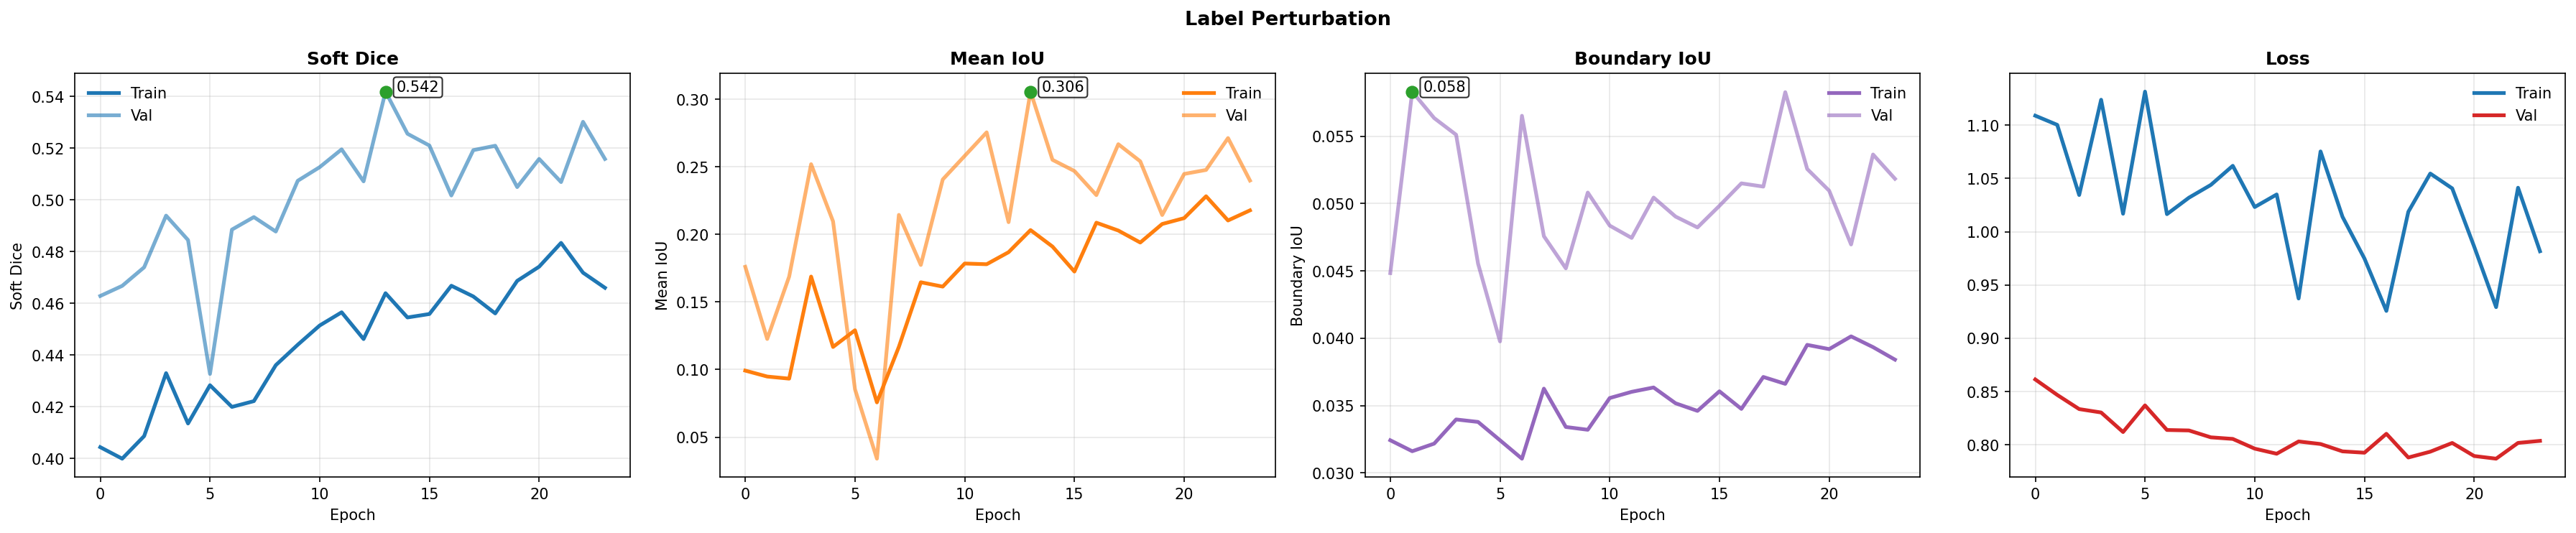

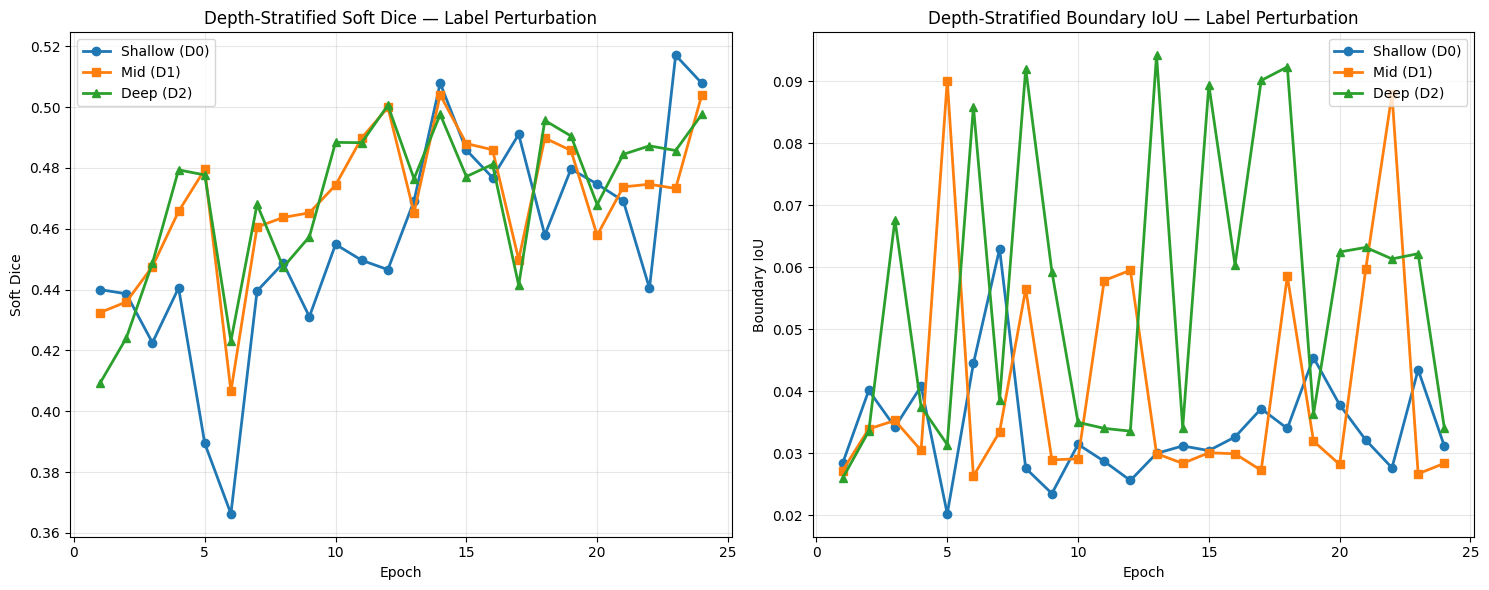

In [77]:
plot_training_curves(label_history, 'Label Perturbation')
plot_depth_metrics(label_callbacks[-1], 'Label Perturbation')

### 8.5 Joint Seismic + Label Perturbation Model

In [78]:
tf.keras.backend.clear_session()
joint_model = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss, lr=1e-4)
joint_model.load_weights('base_model_best_dice.h5')
joint_callbacks = make_perturb_callbacks('joint_model', val_gen)

joint_history = joint_model.fit(
    seismic_perturbation_gen(
        label_perturbation_gen(train_gen, perturbation_prob=0.50),
        perturbation_prob=0.50),
    validation_data=val_gen,
    steps_per_epoch=len(train_gen),
    epochs=75,
    callbacks=joint_callbacks, verbose=1,
)
joint_model.save('models/joint_model_final.h5')
print("✅ Joint perturbation model trained and saved.")

Epoch 1/75
91/91 [==============================] - ETA: 0s - loss: 1.1423 - soft_dice_coef: 0.3937 - mean_iou: 0.0424 - boundary_iou: 0.0327 - distance_weighted_bce: 0.5123 - boundary_dice_loss: 0.9370
Epoch 1: val_boundary_iou improved from -inf to 0.04713, saving model to joint_model_best_biou.h5

Epoch 1: val_soft_dice_coef improved from -inf to 0.45023, saving model to joint_model_best_dice.h5

  [Depth] Epoch 1 | Dice=0.4184 | bIoU=0.0280
    D0: Dice=0.4139±0.171  bIoU=0.0307  (33 patches)
    D1: Dice=0.4205±0.183  bIoU=0.0282  (34 patches)
    D2: Dice=0.4208±0.156  bIoU=0.0251  (33 patches)
91/91 [==============================] - 151s 2s/step - loss: 1.1423 - soft_dice_coef: 0.3937 - mean_iou: 0.0424 - boundary_iou: 0.0327 - distance_weighted_bce: 0.5123 - boundary_dice_loss: 0.9370 - val_loss: 0.8583 - val_soft_dice_coef: 0.4502 - val_mean_iou: 0.0405 - val_boundary_iou: 0.0471 - val_distance_weighted_bce: 0.5801 - val_boundary_dice_loss: 0.9106 - lr: 1.0000e-04
Epoch 2/75


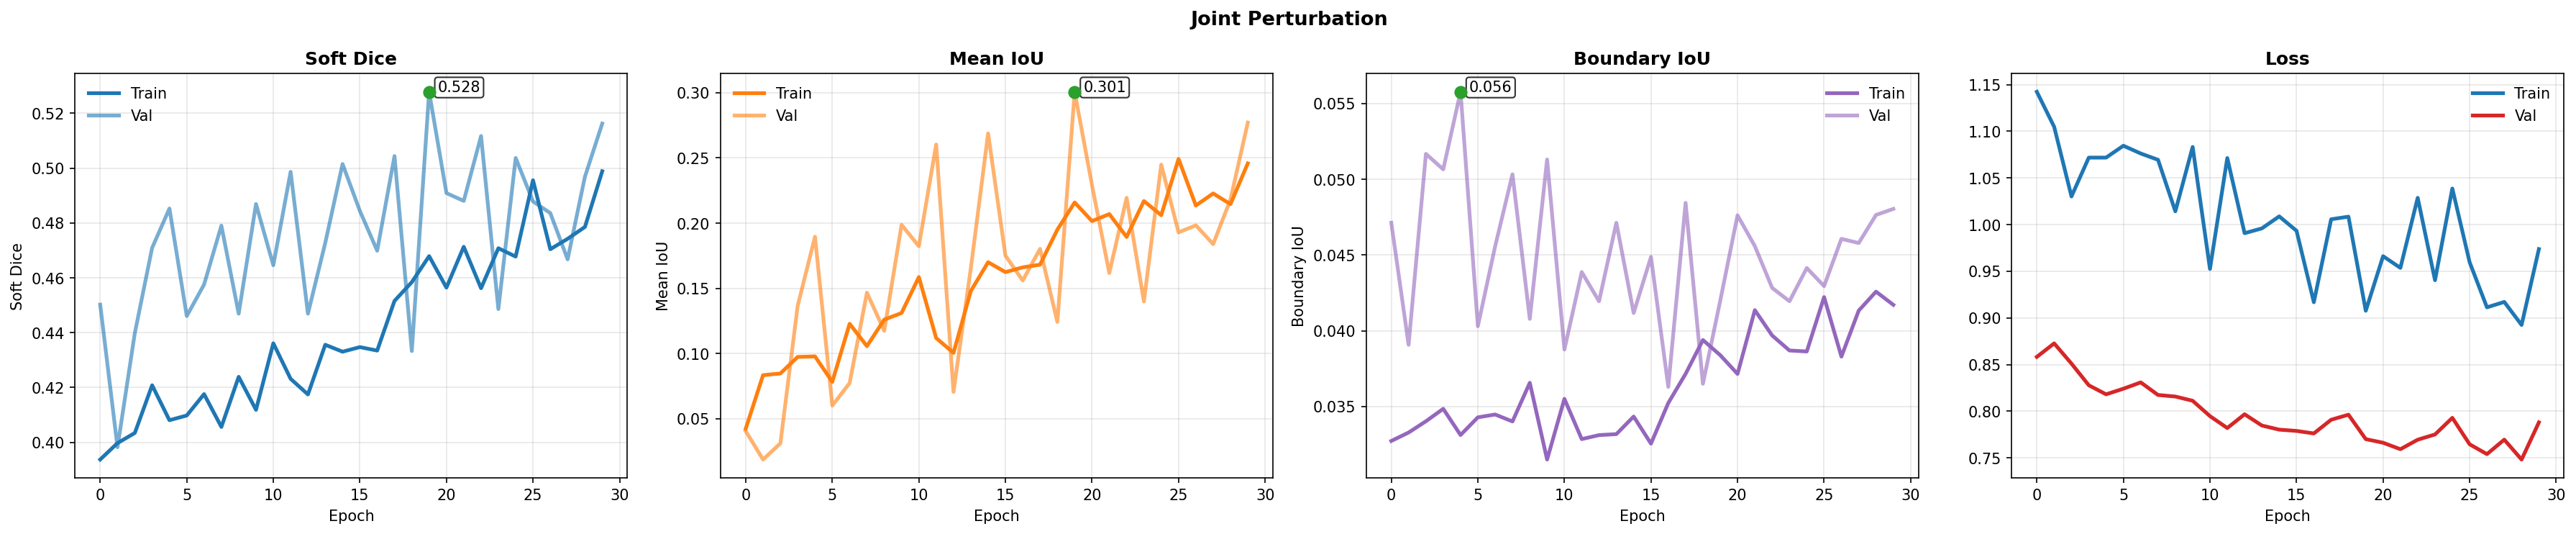

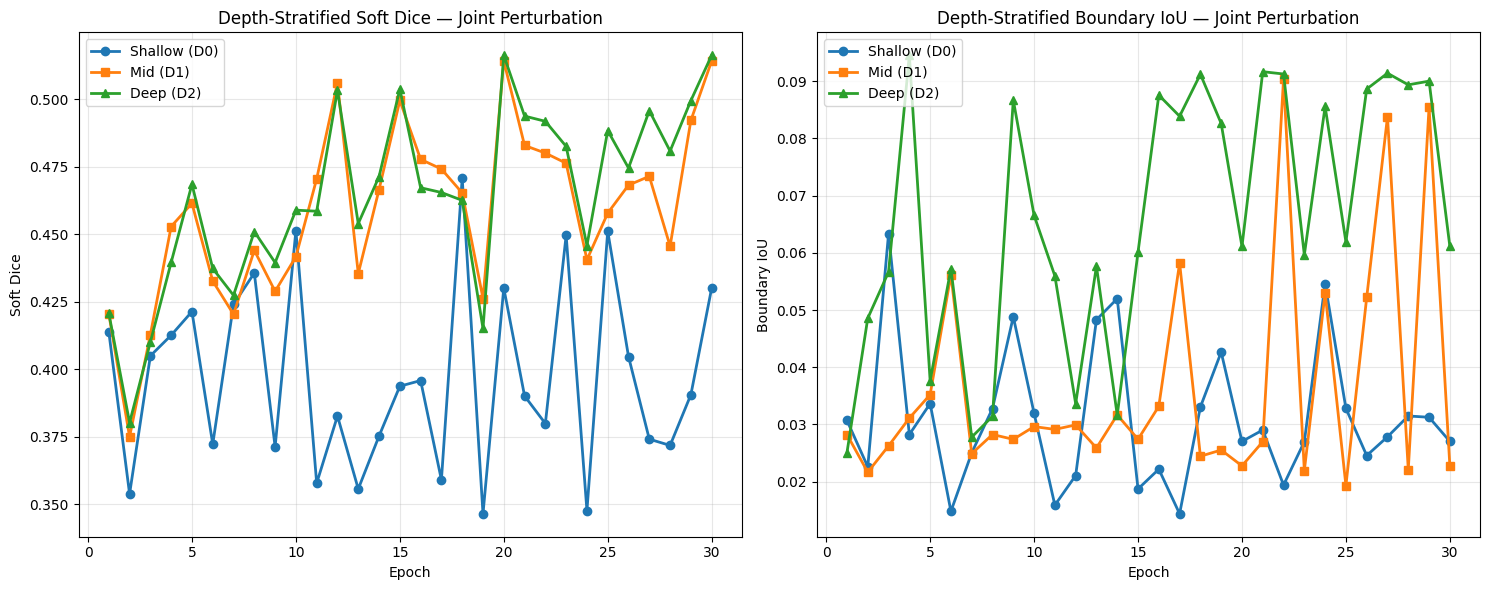

In [79]:
plot_training_curves(joint_history, 'Joint Perturbation')
plot_depth_metrics(joint_callbacks[-1], 'Joint Perturbation')

## 9. Perturbation Results — Quantitative Summary

All metrics are extracted from the **single best checkpoint** (monitored by `val_soft_dice_coef`) for each model, ensuring no optimistic multi-checkpoint reporting.

In [80]:
def best_from_history(h, name):
    ep = int(np.argmax(h.history['val_soft_dice_coef']))
    return {'Model': name,
            'Best epoch': ep + 1,
            'Dice':         round(h.history['val_soft_dice_coef'][ep], 4),
            'Mean IoU':     round(h.history['val_mean_iou'][ep],       4),
            'Boundary IoU': round(h.history['val_boundary_iou'][ep],   4)}

perturb_rows = [
    best_from_history(base_history,    'Base model'),
    best_from_history(seismic_history, 'Seismic perturbed'),
    best_from_history(label_history,   'Label perturbed'),
    best_from_history(joint_history,   'Joint (seismic + label)'),
]
perturb_df = pd.DataFrame(perturb_rows)
display(perturb_df)

# Save to CSV
perturb_df.to_csv('models/perturbation_summary.csv', index=False)
print("Saved: models/perturbation_summary.csv")

,Model,Best epoch,Dice,Mean IoU,Boundary IoU
0,Base model,4,0.5029,0.2623,0.0491
1,Seismic perturbed,3,0.5026,0.2649,0.0474
2,Label perturbed,14,0.5418,0.3056,0.0490
3,Joint (seismic + label),20,0.5279,0.3007,0.0420


Saved: models/perturbation_summary.csv


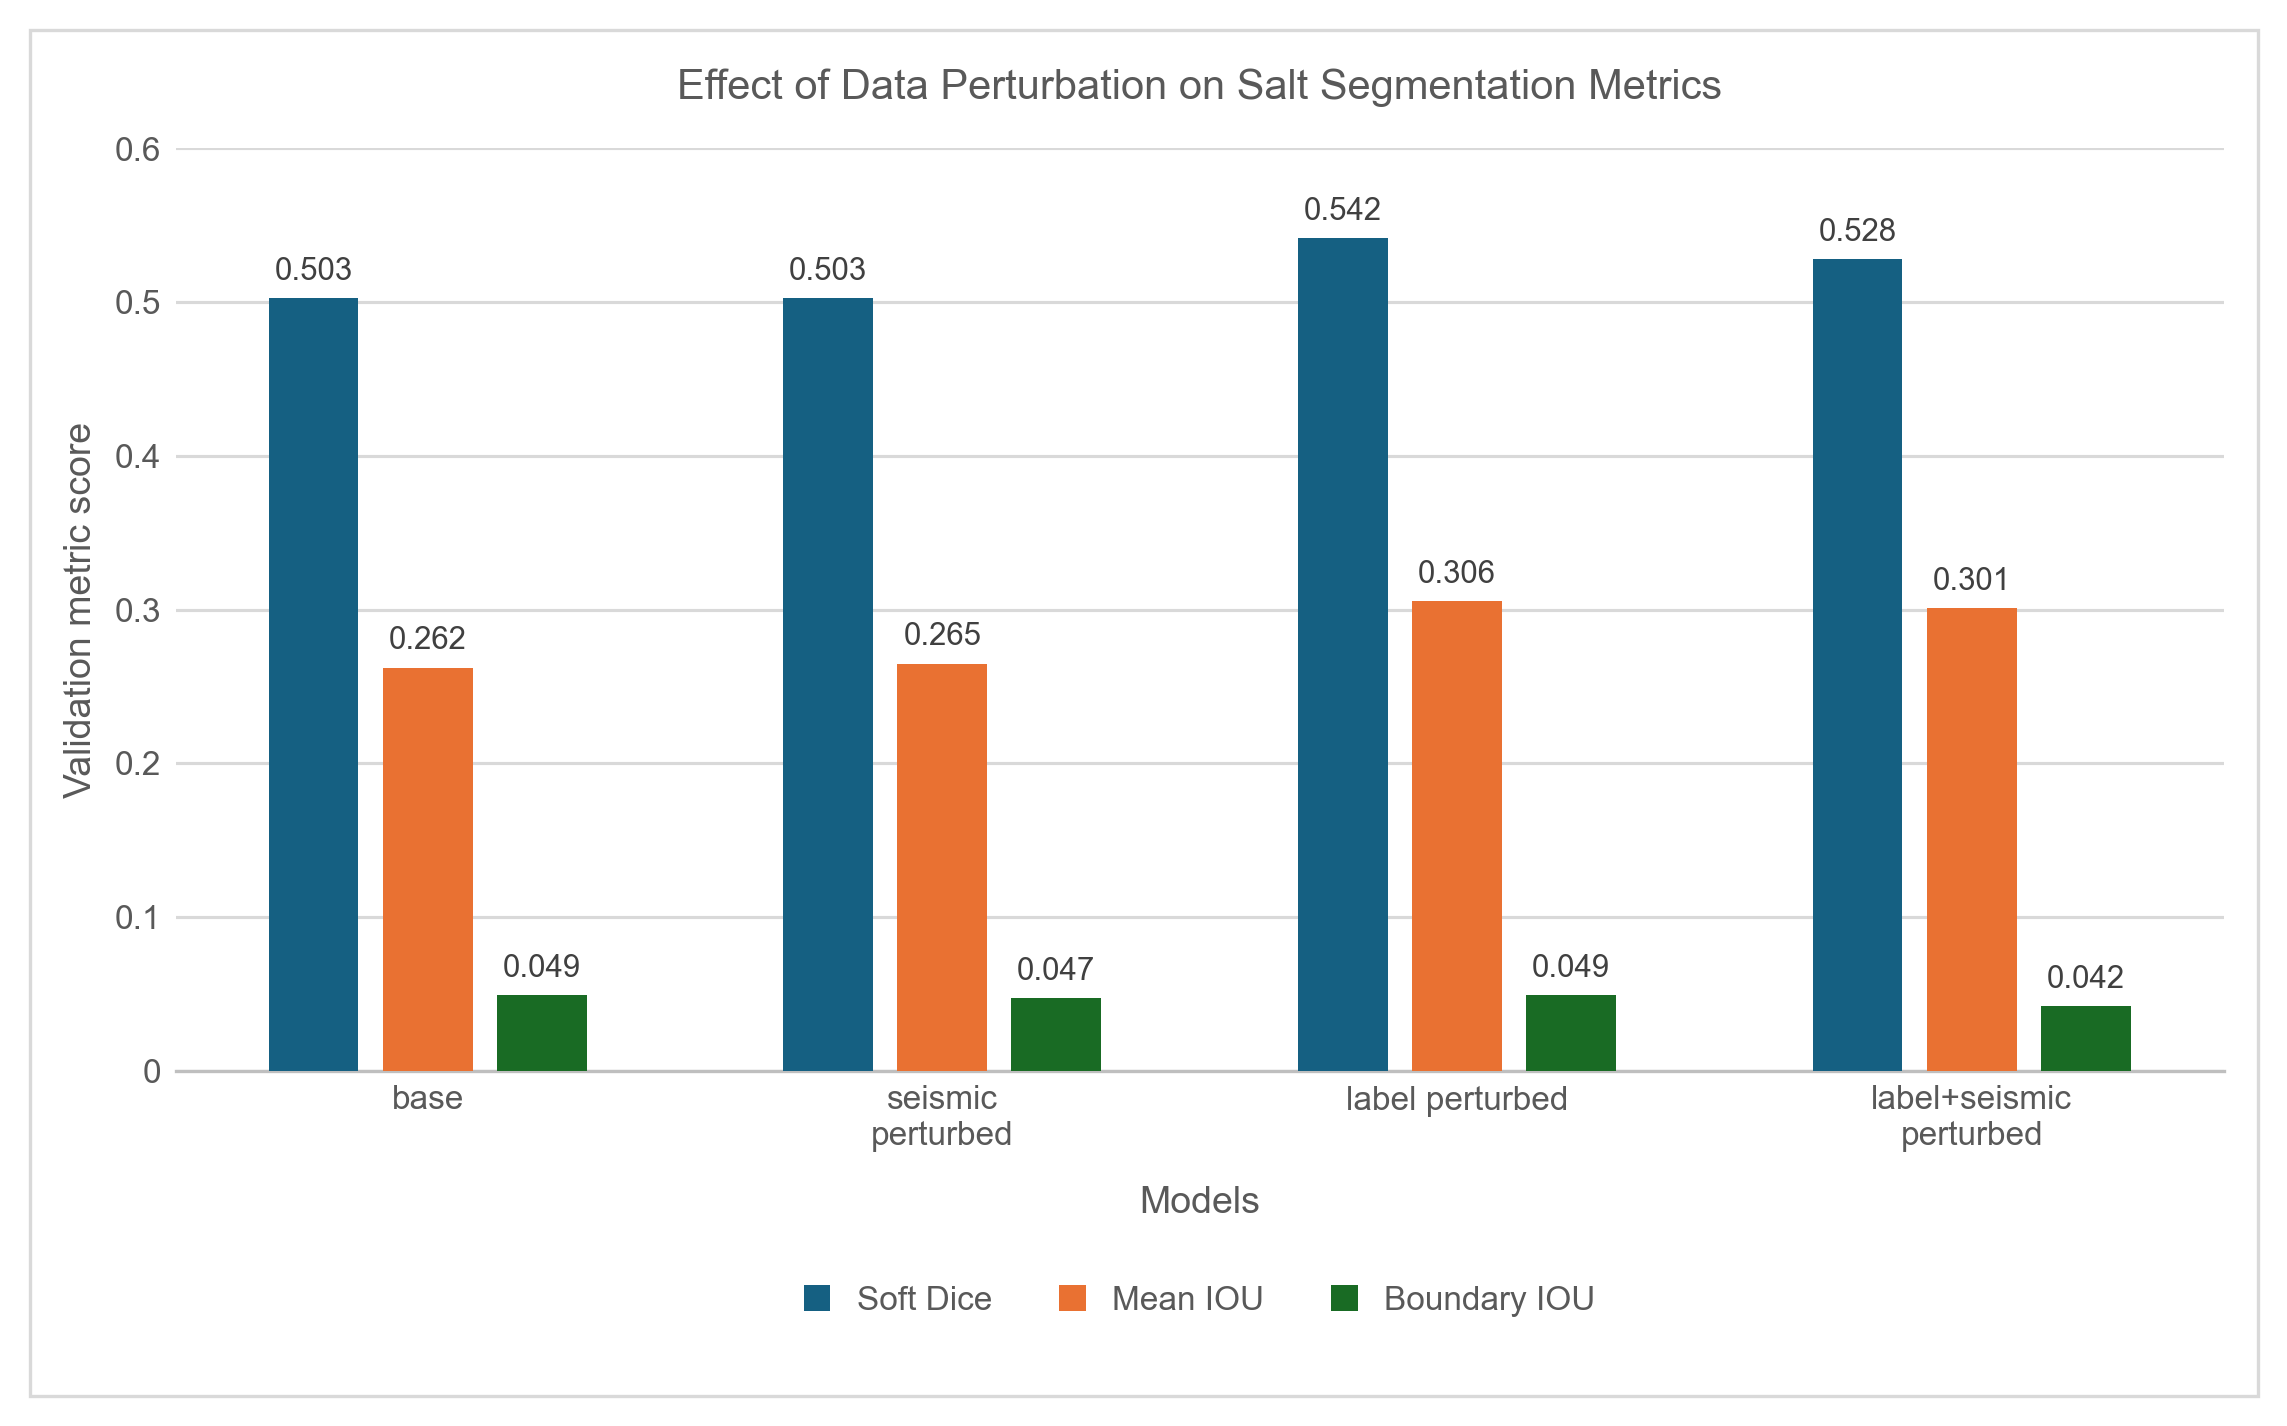

In [87]:
# ── Grouped bar chart in the style of the original Fig. 12 ──────────────────
import textwrap
from matplotlib.patches import Rectangle

plt.rcParams['font.family'] = 'Arial'   # falls back to a sans-serif if Arial is missing
metrics = [('Dice', 'Soft Dice', '#156082'), ('Mean IoU', 'Mean IOU', '#E97132'),
           ('Boundary IoU', 'Boundary IOU', '#196B24')]
models  = ['base', 'seismic perturbed', 'label perturbed', 'label+seismic perturbed']  # same order as perturb_df rows

df = perturb_df[~perturb_df['Model'].str.contains('nsemble')].reset_index(drop=True)
assert len(df) == len(models), f"expected {len(models)} models, got {len(df)}"

# Excel geometry: gap width 219 %, overlap -27 %  ->  bar width in category units
gap, overlap, n = 2.19, -0.27, len(metrics)
w = 1.0 / (n + (n - 1) * -overlap + gap)
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(7.5, 4.6), dpi=300)
for k, (col, name, color) in enumerate(metrics):
    pos  = x + (k - (n - 1) / 2) * w * (1 - overlap)
    bars = ax.bar(pos, df[col], width=w, color=color, label=name, zorder=3)
    for b, v in zip(bars, df[col]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.008, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7.5, color='#404040')

ax.set_ylim(0, np.ceil(df[[m[0] for m in metrics]].values.max() * 10 + 0.5) / 10)   # zero baseline
ax.set_yticks(np.arange(0, ax.get_ylim()[1] + 1e-9, 0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_xticks(x)
ax.set_xticklabels([textwrap.fill(m, 16) for m in models], fontsize=8, color='#595959')
ax.tick_params(axis='y', labelsize=8, colors='#595959', length=0)
ax.tick_params(axis='x', length=0)
ax.grid(axis='y', color='#D9D9D9', linewidth=0.75, zorder=0)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color('#BFBFBF')

ax.set_title('Effect of Data Perturbation on Salt Segmentation Metrics', fontsize=10, color='#595959', pad=12)
ax.set_xlabel('Models', fontsize=9, color='#595959', labelpad=8)
ax.set_ylabel('Validation metric score', fontsize=9, color='#595959')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False,
          fontsize=8, handlelength=0.8, handleheight=0.8, labelcolor='#595959')

plt.tight_layout()
fig.patches.append(Rectangle((0.005, 0.005), 0.99, 0.99, transform=fig.transFigure,
                             fill=False, edgecolor='#D9D9D9', linewidth=0.8))   # chart border
plt.savefig('models/perturbation_comparison.png', dpi=500, facecolor='white')
plt.savefig('models/perturbation_comparison.pdf')   # vector copy for the journal
plt.show(); plt.close()

## 10. Ensemble Prediction & Quantitative Evaluation

The four models are averaged to produce the final salt probability volume. Ensemble metrics are computed on the same 101-patch validation set and added to the summary table.

In [82]:
# ── Load best checkpoints ────────────────────────────────────────────────────
tf.keras.backend.clear_session()
ens_models = []
for name, ckpt in [('base',    'base_model_best_dice.h5'),
                   ('seismic', 'seismic_model_best_dice.h5'),
                   ('label',   'label_model_best_dice.h5'),
                   ('joint',   'joint_model_best_dice.h5')]:
    m = resunet_3d(use_se=True, loss_fn=salt_ultimate_loss)
    m.load_weights(ckpt)
    ens_models.append(m)
    print(f"  Loaded: {ckpt}")

# Binarisation threshold (reported explicitly per reviewer request)
THRESHOLD = 0.50
print(f"\nBinarisation threshold: {THRESHOLD}")

  Loaded: base_model_best_dice.h5
  Loaded: seismic_model_best_dice.h5
  Loaded: label_model_best_dice.h5
  Loaded: joint_model_best_dice.h5

Binarisation threshold: 0.5


In [83]:
# ── Compute ensemble metrics on the validation set ───────────────────────────
ens_dice_list, ens_miou_list, ens_biou_list = [], [], []

for i in range(len(val_gen)):
    Xv, yt, _ = val_gen[i]
    # Average probabilities across the four models
    avg_prob = np.mean([m.predict(Xv, verbose=0) for m in ens_models], axis=0)
    yp_bin   = (avg_prob > THRESHOLD).astype(np.float32)

    for j in range(len(Xv)):
        yt_ = np.squeeze(yt[j])
        yps = np.squeeze(avg_prob[j])
        ypb = np.squeeze(yp_bin[j])
        inter  = np.sum(yt_ * yps)
        usq    = np.sum(np.square(yt_)) + np.sum(np.square(yps))
        dice   = (2 * inter + 1e-6) / (usq + 1e-6)
        miou_i = (np.sum(yt_ * ypb) + 1e-6) / (np.sum(yt_) + np.sum(ypb) - np.sum(yt_*ypb) + 1e-6)
        biou_i = numpy_boundary_iou(yt_, ypb, bw=2)
        ens_dice_list.append(dice)
        ens_miou_list.append(miou_i)
        ens_biou_list.append(biou_i)

ens_row = {'Model': 'Ensemble (avg)',
           'Best epoch': '—',
           'Dice':         round(np.mean(ens_dice_list), 4),
           'Mean IoU':     round(np.mean(ens_miou_list), 4),
           'Boundary IoU': round(np.mean(ens_biou_list), 4)}

full_df = pd.concat([perturb_df, pd.DataFrame([ens_row])], ignore_index=True)
display(full_df)
full_df.to_csv('models/full_results_with_ensemble.csv', index=False)
print("\nSaved: models/full_results_with_ensemble.csv")

,Model,Best epoch,Dice,Mean IoU,Boundary IoU
0,Base model,4,0.5029,0.2623,0.0491
1,Seismic perturbed,3,0.5026,0.2649,0.0474
2,Label perturbed,14,0.5418,0.3056,0.0490
3,Joint (seismic + label),20,0.5279,0.3007,0.0420
4,Ensemble (avg),—,0.4894,0.2785,0.0490



Saved: models/full_results_with_ensemble.csv


## 11. Combined Results Tables for Manuscript

In [84]:
print("=" * 60)
print("TABLE 3 — Perturbation Experiment Results")
print("=" * 60)
print(full_df[['Model','Dice','Mean IoU','Boundary IoU']].to_string(index=False))

print("\n" + "=" * 60)
print("TABLE 4 — Ablation Study Results")
print("=" * 60)
abl_display = ablation_df[['Config','Dice mu','Dice sd','mIoU mu','mIoU sd','bIoU mu','bIoU sd']].copy()
abl_display['Soft Dice']    = abl_display.apply(lambda r: f"{r['Dice mu']:.3f}±{r['Dice sd']:.3f}", axis=1)
abl_display['Mean IoU']     = abl_display.apply(lambda r: f"{r['mIoU mu']:.3f}±{r['mIoU sd']:.3f}", axis=1)
abl_display['Boundary IoU'] = abl_display.apply(lambda r: f"{r['bIoU mu']:.3f}±{r['bIoU sd']:.3f}", axis=1)
print(abl_display[['Config','Soft Dice','Mean IoU','Boundary IoU']].to_string(index=False))

TABLE 3 — Perturbation Experiment Results
                  Model   Dice  Mean IoU  Boundary IoU
             Base model 0.5029    0.2623        0.0491
      Seismic perturbed 0.5026    0.2649        0.0474
        Label perturbed 0.5418    0.3056        0.0490
Joint (seismic + label) 0.5279    0.3007        0.0420
         Ensemble (avg) 0.4894    0.2785        0.0490

TABLE 4 — Ablation Study Results
                                 Config   Soft Dice    Mean IoU Boundary IoU
                      A: Plain 3D U-Net 0.605±0.004 0.390±0.006  0.051±0.002
                  B: 3D ResUNet (no SE) 0.604±0.009 0.397±0.004  0.051±0.005
                       C: 3D SE-ResUNet 0.582±0.011 0.364±0.015  0.046±0.002
         D: SE-ResUNet + Composite Loss 0.545±0.038 0.310±0.039  0.049±0.002
  E: Full SE-ResUNet + Depth-Stratified 0.537±0.022 0.293±0.021  0.048±0.001
F: Full Model + Depth-Bin-Weighted Loss 0.513±0.006 0.263±0.006  0.051±0.002
